## Mobile Price Range Prediction Project!! 

Lavina has started her own mobile company. She wants to put up a tough fight against big companies like Apple and Samsung. 

She does not know how to estimate the price of the mobiles that her company creates. In this competitive mobile phone market, you cannot simply assume things. To solve this problem, he collects sales data of mobile phones of various companies. 

Bob wants to find out the relationship between features of a mobile phone (e.g., RAM, Internal Memory, etc.) and its selling price. But he is not so good at Machine Learning. So he needs your help to solve this problem. 

In this problem, you do not have to predict the actual price, but rather a price range indicating how high it is. 

In [1]:
# Importing libraries 

import pandas as pd 
import numpy as np

In [2]:
# Reading and loading the dataset. 

data = pd.read_csv("train.csv")  

In [3]:
df = pd.DataFrame(data) 

# Phase 1: Data Understanding

- Import libraries.
- Load train.csv and test.csv.
- Inspect shape, columns, data types.
- Understand what every feature means.

In [4]:
# Lets understand the data thoroughly. 

df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [5]:
df.tail()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0
1999,510,1,2.0,1,5,1,45,0.9,168,6,...,483,754,3919,19,4,2,1,1,1,3


Observation: 

Out of 21 columns one is target variable i.e. Y = price_range. 
Now out of 20 columns gotta find out the important input features i.e. X. 

Now let's study the whole dataset properly with each column ahead. 

In [6]:
df.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

Understanding columns: 

| Column        | Meaning                                             | Type                 | Why it might affect price                                               |
| --------------| --------------------------------------------------- | -------------------- | ----------------------------------------------------------------------- |
| battery_power | Battery capacity (mAh)                              | Numerical            | Larger battery usually increases the price.                             |
| blue          | Does the phone support Bluetooth? (0 = No, 1 = Yes) | Binary               | Basic feature; may have a small effect.                                 |
| clock_speed   | CPU clock speed (GHz)                               | Numerical            | Faster processor generally means better performance and a higher price. |
| dual_sim      | Dual SIM support? (0 = No, 1 = Yes)                 | Binary               | Common feature today, may have a small impact.                          |
| fc            | Front camera megapixels (MP)                        | Numerical            | Better selfie camera can increase price.                                |
| four_g        | Supports 4G? (0 = No, 1 = Yes)                      | Binary               | Important network feature, especially in modern phones.                 |
| int_memory    | Internal storage (GB)                               | Numerical            | More storage usually means a higher price.                              |
| m_dep         | Mobile depth/thickness (cm)                         | Numerical            | Physical thickness of the phone. May have little effect on price.       |
| mobile_wt     | Weight of the phone (grams)                         | Numerical            | Mostly a design characteristic; not always strongly related to price.   |
| n_cores       | Number of CPU cores                                 | Numerical (Discrete) | More cores often indicate a more powerful processor.                    |
| pc            | Primary (rear) camera megapixels (MP)               | Numerical            | Better rear camera often increases price.                               |
| px_height     | Screen resolution height (pixels)                   | Numerical            | Higher resolution usually means a better display.                       |
| px_width      | Screen resolution width (pixels)                    | Numerical            | Used with px_height to determine display quality.                       |
| ram           | RAM (MB)                                            | Numerical            | One of the strongest factors affecting phone price.                     |
| sc_h          | Screen height (cm)                                  | Numerical            | Physical screen size.                                                   |
| sc_w          | Screen width (cm)                                   | Numerical            | Physical screen size.                                                   |
| talk_time     | Battery talk time (hours)                           | Numerical            | Longer battery life can increase value.                                 |
| three_g       | Supports 3G? (0 = No, 1 = Yes)                      | Binary               | Older network technology.                                               |
| touch_screen  | Touch screen available? (0 = No, 1 = Yes)           | Binary               | Important feature but almost all modern phones have it.                 |
| wifi          | Wi-Fi support? (0 = No, 1 = Yes)                    | Binary               | Standard connectivity feature.                                          |
| price_range   | Target variable (0–3)                               | Target               | The category your model must predict.                                   |

Potentially Important Features: [ Battery Power , clock speed, fc , 4 G , int memory , n cores , pc , px height , px width , RAM , sc h and sc w (can be area screen) , talk time , touch screen , wifi ] 

OBSERVATIONS: 

• Dataset contains 2000 observations(rows).
• Dataset has 21 columns. 
• Target variable(Y) appears to be 'price_range'.
• Since the target is categorical (0–3), this is a multiclass classification problem.  

# Phase 2: Data Quality Assessment
- Missing values
- Duplicate values
- Data consistency
- Target distribution 

In [7]:
# Missing Value Check : No missing values are present. Therefore, no imputation is required. 

df.isnull().sum().sum() # if the dataset has any missing values.

np.int64(0)

In [8]:
# Duplicate rows : The dataset contains no duplicate records. Each observation represents a unique mobile phone configuration.

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [9]:
# Duplicate Columns : No duplicate feature names are present, indicating a well-structured dataset. 

duplicate_columns = df.columns[df.columns.duplicated()]
print("Duplicate Columns:", duplicate_columns)

Duplicate Columns: Index([], dtype='object')


Reasoning for value count :

- Used unique() for binary and categorical features because the number of distinct values is small and easy to inspect.
- Used nunique() for continuous features because printing hundreds or thousands of values is not informative. 

In [10]:
# Unique Value Count:  

df.nunique()  

battery_power    1094
blue                2
clock_speed        26
dual_sim            2
fc                 20
four_g              2
int_memory         63
m_dep              10
mobile_wt         121
n_cores             8
pc                 21
px_height        1137
px_width         1109
ram              1562
sc_h               15
sc_w               19
talk_time          19
three_g             2
touch_screen        2
wifi                2
price_range         4
dtype: int64

In [11]:
# Binary Verification : Every binary column contains only 0 & 1.  

# df.apply(lambda col: col.unique()) If want for all the columns, but since some have large count we will inspect which is needed here. 

columns = ["blue", "dual_sim", "four_g", "three_g", "touch_screen", "wifi", "price_range"] 

for i in columns:  
    print( f"{i} = {df[i].unique()}")   

blue = [0 1]
dual_sim = [0 1]
four_g = [0 1]
three_g = [0 1]
touch_screen = [0 1]
wifi = [1 0]
price_range = [1 2 3 0]


In [12]:
# Binary Column Distribution 

binary_columns = [ "blue","dual_sim","four_g","three_g","touch_screen","wifi" ]

for i in binary_columns:
    print( df[i].value_counts().sort_index() ) 
    print("\n")

blue
0    1010
1     990
Name: count, dtype: int64


dual_sim
0     981
1    1019
Name: count, dtype: int64


four_g
0     957
1    1043
Name: count, dtype: int64


three_g
0     477
1    1523
Name: count, dtype: int64


touch_screen
0     994
1    1006
Name: count, dtype: int64


wifi
0     986
1    1014
Name: count, dtype: int64




In [13]:
# TARGET COLUMN DISTRIBUTION IN DATASET: 

df['price_range'].value_counts().sort_index()

price_range
0    500
1    500
2    500
3    500
Name: count, dtype: int64

In [14]:
# Percentage: 

(df["price_range"].value_counts(normalize=True) * 100).sort_index()

price_range
0    25.0
1    25.0
2    25.0
3    25.0
Name: proportion, dtype: float64

OBSERVATION OF TARGET VARIABLE : 

The target variable is perfectly balanced, with each price category representing 25% of the dataset. Therefore, no class imbalance handling techniques (such as oversampling or class weighting) are required. 

In [15]:
# Statistical Summary : 

df.describe().T

,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,1238.51850,439.418206,501.0,851.75,1226.0,1615.25,1998.0
blue,2000.0,0.49500,0.500100,0.0,0.00,0.0,1.00,1.0
clock_speed,2000.0,1.52225,0.816004,0.5,0.70,1.5,2.20,3.0
dual_sim,2000.0,0.50950,0.500035,0.0,0.00,1.0,1.00,1.0
fc,2000.0,4.30950,4.341444,0.0,1.00,3.0,7.00,19.0
four_g,2000.0,0.52150,0.499662,0.0,0.00,1.0,1.00,1.0
int_memory,2000.0,32.04650,18.145715,2.0,16.00,32.0,48.00,64.0
m_dep,2000.0,0.50175,0.288416,0.1,0.20,0.5,0.80,1.0
mobile_wt,2000.0,140.24900,35.399655,80.0,109.00,141.0,170.00,200.0
n_cores,2000.0,4.52050,2.287837,1.0,3.00,4.0,7.00,8.0


OBSERVATION : 

- RAM : Median = 2146 & Mean = 2124  =>  Mean ≈ Median [ That usually suggests the distribution is fairly symmetric. ] 

In [16]:
# Checking data range: 

important_features = [ "battery_power", "ram", "int_memory", "clock_speed", "mobile_wt", "talk_time" ]

df[important_features].agg(["min", "max"]) 

,battery_power,ram,int_memory,clock_speed,mobile_wt,talk_time
min,501,256,2,0.5,80,2
max,1998,3998,64,3.0,200,20


Data Quality Assessment

After performing initial quality checks, the dataset appears to be clean and well-prepared for exploratory data analysis.

Key Findings:

- No missing values.
- No duplicate rows.
- No duplicate columns.
- All binary variables contain valid values (0 or 1).
- The target variable is perfectly balanced across all four classes.
- Data ranges appear realistic with no obvious invalid values.

Conclusion:

No preprocessing or cleaning is required at this stage. The dataset is ready for exploratory data analysis (EDA).

number alone → histogram 
number vs number → scatter plot 
category vs number → box plot / bar chart 
many numbers → heatmap 

# Phase 3: Exploratory Data Analysis (EDA)
- Univariate Analysis
- Bivariate Analysis
- Feature-wise observations
- Business interpretation 

Rule: Only ONE feature at a time. 

| Feature         | Relationship                      | Confidence | EDA Decision                          |
| --------------- | --------------------------------- | ---------- | ------------------------------------- |
| RAM             | Strong Positive                   | ⭐⭐⭐⭐⭐      | **Keep (High Priority)**              |
| Battery Power   | Moderate Positive                 | ⭐⭐⭐⭐☆      | **Keep**                              |
| Internal Memory | Moderate Positive                 | ⭐⭐⭐⭐☆      | **Keep**                              |
| Pixel Height    | Strong Positive                   | ⭐⭐⭐⭐⭐      | **Keep (High Priority)**              |
| Pixel Width     | Moderate Positive                 | ⭐⭐⭐⭐☆      | **Keep**                              |
| 4G              | Moderate Positive                 | ⭐⭐⭐⭐☆      | **Keep**                              |
| Front Camera    | Weak to Moderate Positive         | ⭐⭐⭐☆☆      | **Keep for Further Evaluation**       |
| Primary Camera  | Weak to Moderate Positive         | ⭐⭐⭐☆☆      | **Keep for Further Evaluation**       |
| 3G              | Weak to Moderate Positive         | ⭐⭐⭐☆☆      | **Keep for Further Evaluation**       |
| Number of Cores | Weak to Moderate Positive         | ⭐⭐⭐☆☆      | **Keep for Further Evaluation**       |
| Clock Speed     | Weak Positive                     | ⭐⭐☆☆☆      | **Evaluate During Feature Selection** |
| Talk Time       | Weak Positive                     | ⭐⭐☆☆☆      | **Evaluate During Feature Selection** |
| Screen Height   | Weak Positive                     | ⭐⭐☆☆☆      | **Evaluate During Feature Selection** |
| Screen Width    | Weak Positive                     | ⭐⭐☆☆☆      | **Evaluate During Feature Selection** |
| Mobile Weight   | Weak / No Clear Relationship      | ⭐⭐☆☆☆      | **Evaluate During Feature Selection** |
| Bluetooth    | Very Weak / No Clear Relationship | ⭐☆☆☆☆      | **Reassess After Feature Selection** |
| WiFi         | Very Weak / No Clear Relationship | ⭐☆☆☆☆      | **Reassess After Feature Selection** |
| Dual SIM     | Very Weak / No Clear Relationship | ⭐☆☆☆☆      | **Reassess After Feature Selection** |
| Touch Screen | Very Weak / No Clear Relationship | ⭐☆☆☆☆      | **Reassess After Feature Selection** |
| Mobile Depth | Very Weak / No Clear Relationship | ⭐☆☆☆☆      | **Reassess After Feature Selection** |


In [17]:
# Importing visualization libraries 

import matplotlib.pyplot as plt
import seaborn as sns

A graph has points : A clear title , X-axis label , Y-axis label , Appropriate figure size , Appropriate number of bins , Readable style. 

How to identify which gragh to choose. 

| Question                                             | Data Type               | Best Plot              |
| ---------------------------------------------------- | ----------------------- | ---------------------- |
| How is one numerical feature distributed?            | Numerical               | Histogram              |
| Are there outliers?                                  | Numerical               | Box Plot               |
| How does a numerical feature vary across categories? | Numerical + Categorical | Box Plot / Violin Plot |
| How are two numerical features related?              | Numerical + Numerical   | Scatter Plot           |
| How many samples are in each category?               | Categorical             | Count Plot             |


# How to read the box plots : 

          ○      ← Outlier

          │
      ─────────    ← Maximum (excluding outliers)

      ┌───────┐
      │       │
      │ ───── │ ← Median (50%)
      │       │
      └───────┘

      ─────────    ← Minimum (excluding outliers)

          ○      ← Outlier 

## Feature Analysis 1: RAM 

# Phase A — Understand the Feature  

In [18]:
df["ram"].describe()

count    2000.000000
mean     2124.213000
std      1084.732044
min       256.000000
25%      1207.500000
50%      2146.500000
75%      3064.500000
max      3998.000000
Name: ram, dtype: float64

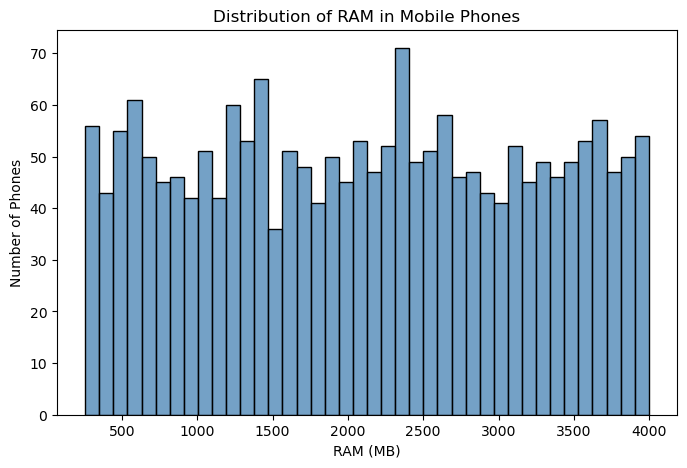

In [19]:
# Ram Histogram 

plt.figure(figsize=(8,5))   
sns.histplot(df["ram"], bins=40, color="steelblue") 
plt.title("Distribution of RAM in Mobile Phones")  
plt.xlabel("RAM (MB)")   
plt.ylabel("Number of Phones")
plt.show() 

### Observations

- Mean and median are very close, indicating an approximately symmetric distribution.
- RAM values range from **256 MB** to **3998 MB**, covering both low-end and high-end smartphones.
- The histogram shows that RAM values are spread across the entire range.
- No single RAM interval dominates the dataset, indicating a fairly balanced distribution.
- No obvious skewness or unusual pattern is observed. 

# Phase B — Compare with Target 

### Business Question
Does RAM influence the mobile phone price range?

### Hypothesis
Phones with higher RAM are expected to belong to higher price categories. Some overlap may exist because price also depends on other specifications (battery, processor, storage, display, etc.). 

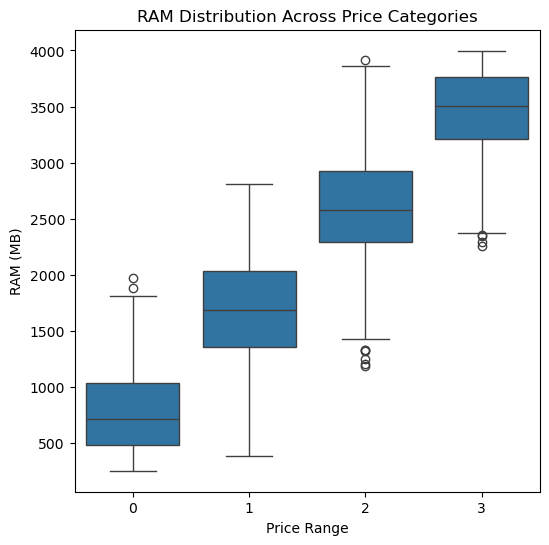

In [20]:
# RAM vs PRICE RANGE 

plt.figure(figsize=(6,6)) 

sns.boxplot( data=df, x="price_range", y="ram" )

plt.title("RAM Distribution Across Price Categories")
plt.xlabel("Price Range")
plt.ylabel("RAM (MB)")

plt.show() 

### Observations
| Observation   | Finding                                               |
|---------------|-------------------------------------------------------|
| Median        | Median RAM increases from Price Range 0 to 3.         |
| Distribution  | The entire RAM distribution shifts upward with price. |
| Overlap       | Slight overlap exists between neighboring categories. |
| Outliers      | A few outliers are present but appear valid.          |
| Overall Trend | Higher price categories generally have higher RAM.    |

### Business Interpretation
RAM shows a strong positive relationship with mobile phone price. As the price category increases, the RAM capacity also increases. 
This suggests that manufacturers generally equip premium smartphones with higher RAM to provide better performance and multitasking capabilities. 

### Decision 
**Keep RAM** as an important feature for model training. 

# Feature Analysis 2: Battery Power

# Phase A — Understand the Feature 

In [21]:
df["battery_power"].describe()

count    2000.000000
mean     1238.518500
std       439.418206
min       501.000000
25%       851.750000
50%      1226.000000
75%      1615.250000
max      1998.000000
Name: battery_power, dtype: float64

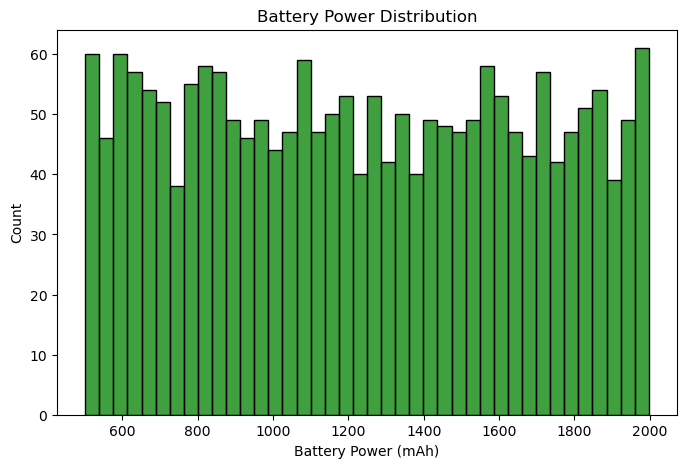

In [22]:
# HISTOGRAM : Battery power 

plt.figure(figsize=(8,5))   

sns.histplot(
    df['battery_power'], 
    bins=40,
    color='green'
)  

plt.title("Battery Power Distribution") 
plt.xlabel("Battery Power (mAh)") 
plt.ylabel("Count")  

plt.show()  

### Observations

- Mean and median are very close, indicating an approximately symmetric distribution.
- Battery power ranges from **501 mAh** to **1998 mAh**, covering devices with different battery capacities.
- The histogram shows battery values are spread across the entire range.
- No single battery capacity dominates the dataset.
- No obvious skewness or unusual distribution pattern is observed.

# Phase B — Compare with Target (Battery Power vs Price Range) 

## Business Question
Does battery power influence the mobile phone price range? 

## Hypothesis
Phones with higher battery power are expected to belong to higher price categories. However, since battery capacity is only one of several hardware specifications, the relationship is expected to be positive but weaker than RAM, with more overlap between price categories.

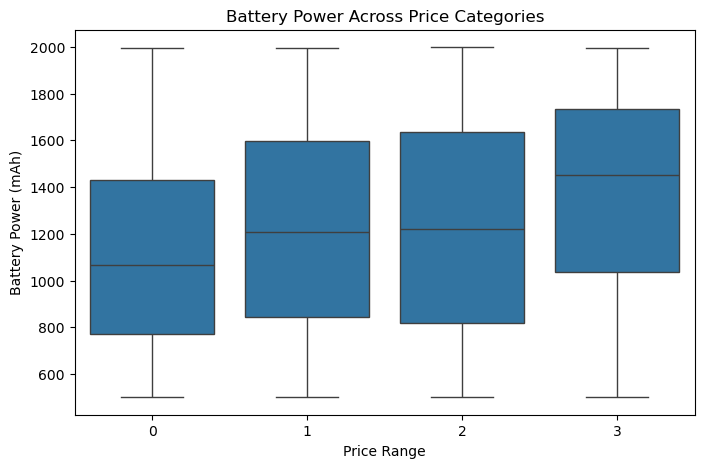

In [23]:
# BOXPLOT : Battery Power VS Price Range 

plt.figure(figsize=(8,5)) 

sns.boxplot(
    data=df, 
    x="price_range", 
    y='battery_power'
)  

plt.title("Battery Power Across Price Categories") 
plt.xlabel("Price Range") 
plt.ylabel("Battery Power (mAh)")  

plt.show() 

### Observations
| Observation       | Finding                                                                                             |
| ----------------- | --------------------------------------------------------------------------------------------------- |
| **Median**        | Median battery power gradually increases from Price Range 0 to 3.                                   |
| **Distribution**  | Battery power is spread across all price categories with a similar spread.                          |
| **Overlap**       | There is considerable overlap between all price categories.                                         |
| **Outliers**      | No noticeable outliers are present.                                                                 |
| **Overall Trend** | Higher price categories generally have higher battery power, but the separation is weaker than RAM. | 

### Business Interpretation
Battery power shows a positive relationship with mobile price.

However, battery capacity alone does not clearly separate the price categories, as phones from different price ranges often have similar battery capacities. This indicates that battery power contributes to pricing but is not a primary deciding factor. 

### Decision
Battery Power demonstrates a **moderate positive** relationship with the target variable (`price_range`).

Therefore, Battery Power should be **retained** as an important feature for model training. 

# Feature Analysis 3 : Internal Memory

# Phase A — Understand the Feature  

In [24]:
df["int_memory"].describe() 

count    2000.000000
mean       32.046500
std        18.145715
min         2.000000
25%        16.000000
50%        32.000000
75%        48.000000
max        64.000000
Name: int_memory, dtype: float64

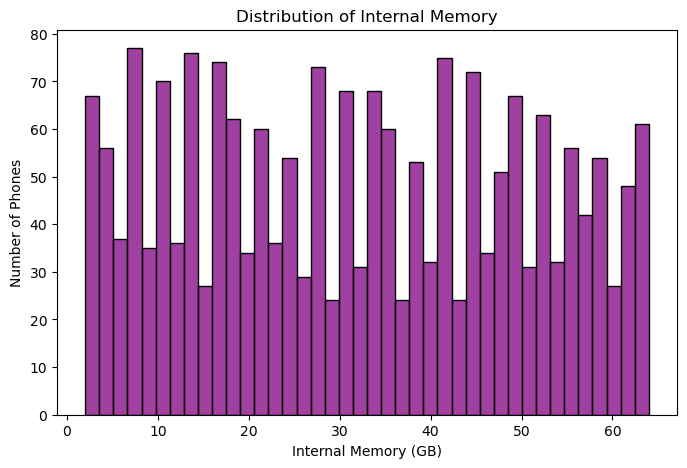

In [25]:
# HISTOGRAM 

plt.figure(figsize=(8,5)) 

sns.histplot(
    df["int_memory"], 
    bins=40, 
    color='purple'
) 

plt.title("Distribution of Internal Memory") 
plt.xlabel("Internal Memory (GB)")
plt.ylabel("Number of Phones")

plt.show() 

### Observations

- Mean and median are almost identical, indicating a balanced distribution.
- Internal memory ranges from **2 GB** to **64 GB**, covering low to high storage capacities.
- Values are spread across the entire range.
- No single storage capacity dominates the dataset.
- The distribution appears fairly uniform with no obvious unusual pattern.

# Phase B — Compare with Target (Internal Memory vs Price Range) 

## Business Question
Does internal memory influence the price range of a mobile phone? 

## Hypothesis
Since internal memory is an important hardware specification, phones with higher internal memory are expected to belong to higher price categories.

However, storage alone does not determine the price. Other features such as RAM, processor, battery, and display also contribute to pricing. Therefore, some overlap between price categories is expected.

Expected Relationship: Positive (Moderate) 

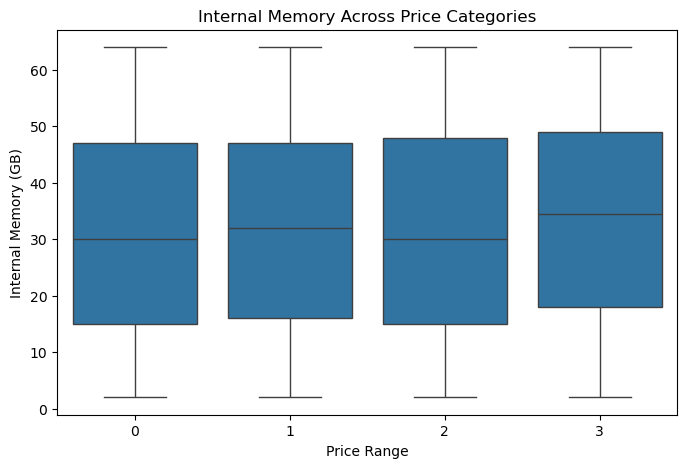

In [26]:
# BOX PLOT : internal memory VS price range 

plt.figure(figsize=(8,5)) 

sns.boxplot(
    data=df, 
    x='price_range', 
    y='int_memory'
) 

plt.title("Internal Memory Across Price Categories")
plt.xlabel("Price Range")
plt.ylabel("Internal Memory (GB)")    

plt.show()  

### Observations

| Observation      | Finding                                                                                         |
|------------------|-------------------------------------------------------------------------------------------------|
| **Median**       | Shows a slight increase overall but is not consistently increasing across all price categories. |
| **Overlap**      | Considerable overlap exists between all price categories.                                       |
| **Outliers**     | No noticeable outliers are present.                                                             |
| **Spread**       | The spread is similar across all price categories.                                              | 
| **Overall Trend**| Internal memory has a positive but moderate relationship with the price range.                  | 

### Business Interpretation
Higher-priced phones generally tend to offer more internal memory, but storage alone is not sufficient to distinguish price categories because of the large overlap.

### Decision
Internal memory has a moderate positive relationship with `price_range`.

Therefore, it should be retained as a useful feature for model training.

# Feature Analysis 4 : Clock Speed

# Phase A — Understand the Feature 

In [27]:
df["clock_speed"].describe() 

count    2000.000000
mean        1.522250
std         0.816004
min         0.500000
25%         0.700000
50%         1.500000
75%         2.200000
max         3.000000
Name: clock_speed, dtype: float64

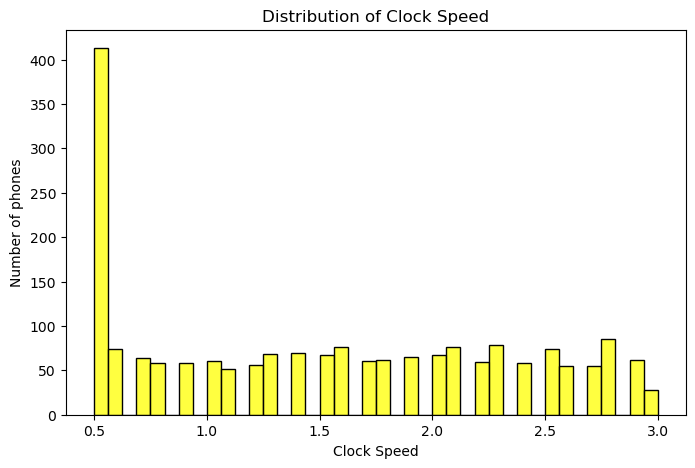

In [28]:
plt.figure(figsize=(8,5)) 

sns.histplot(
    df["clock_speed"],  
    bins=40,
    color='yellow'
) 

plt.title("Distribution of Clock Speed") 
plt.xlabel("Clock Speed") 
plt.ylabel("Number of phones") 

plt.show()  

### Observations

- The histogram is not symmetric.
- Most clock speed values are spread across the full range (0.5–3.0 GHz).
- A noticeable peak is present at **0.5 GHz**, where the highest number of phones is concentrated.
- Apart from the first peak, the remaining clock speed values are fairly evenly distributed.
- The feature covers a wide range of clock speeds and appears suitable for model training.

# Phase B — Compare with Target (Clock Speed vs Price Range) 

## Business Question
Does clock speed influence the mobile phone price range? 

## Hypothesis 
- Relationship: Positive
- Expected Strength: Weak to Moderate
- Expected Overlap: High
- Reason:
Clock speed contributes to processor performance, so phones with higher clock speeds may be priced higher. However, price also depends on other hardware specifications such as RAM, internal memory, battery power, and processor architecture. Therefore, considerable overlap between price categories is expected.

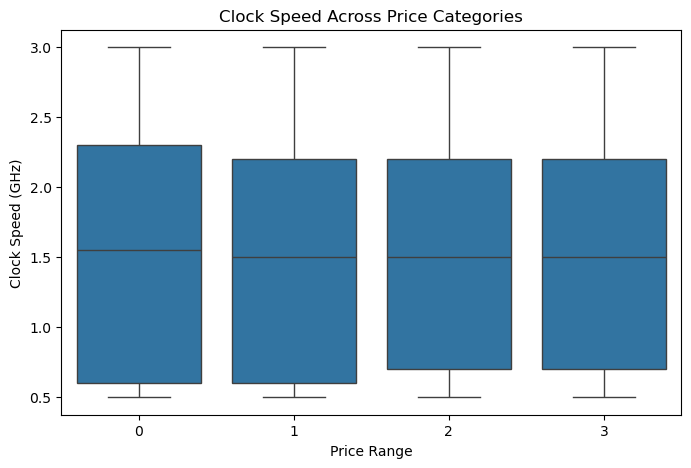

In [29]:
# BOX PLOT : Clock Speed VS Price Range 

plt.figure(figsize=(8,5)) 

sns.boxplot( 
    data=df, 
    x=("price_range"),  
    y=("clock_speed") 
) 

plt.title("Clock Speed Across Price Categories") 
plt.xlabel("Price Range") 
plt.ylabel("Clock Speed (GHz)") 

plt.show() 

# Observation 
| Observation       | Finding                                                                                                    |
| ----------------- | ---------------------------------------------------------------------------------------------------------- |
| **Median**        | The median clock speed remains nearly the same across all price ranges, with only a very slight variation. |
| **Overlap**       | The boxplots overlap heavily across all four price categories.                                             |
| **Outliers**      | No significant outliers are visible.                                                                       |
| **Spread (IQR)**  | The spread is very similar across all price categories, with only minor differences in box size.           |
| **Overall Trend** | There is no clear increasing trend in clock speed as price range increases.                                |

## Business Interpretation
Clock speed alone does not clearly distinguish low-priced phones from high-priced phones. Similar clock speed values appear across all price categories, indicating that pricing depends on additional specifications rather than clock speed alone. 

### Decision 
Keep the feature for model training, as it may provide useful information when combined with other features.

# Feature Analysis 5 : Mobile Weight

# Phase A — Understand the Feature 

In [30]:
df["mobile_wt"].describe() 

count    2000.000000
mean      140.249000
std        35.399655
min        80.000000
25%       109.000000
50%       141.000000
75%       170.000000
max       200.000000
Name: mobile_wt, dtype: float64

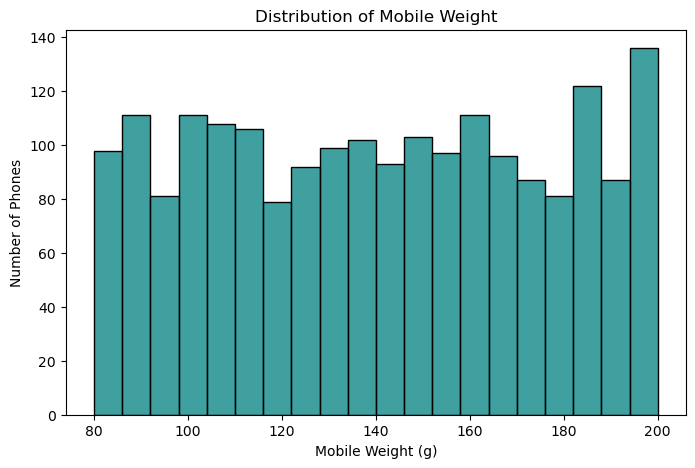

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["mobile_wt"],
    bins=20,
    color="teal"
)

plt.title("Distribution of Mobile Weight")
plt.xlabel("Mobile Weight (g)")
plt.ylabel("Number of Phones")

plt.show() 

### Observations 
- The distribution is approximately uniform across most of the weight range.
- Mobile weights are spread throughout the entire range (80 g – 200 g).
- A noticeable concentration of phones is observed between **180 g and 200 g**.
- No obvious gaps or clusters are present in the distribution.
- The feature covers a wide range of mobile weights and appears suitable for model training.

# Phase B — Compare with Target (Mobile Weight vs Price Range) 

## Business Question
Does mobile weight influence the mobile phone price range?

## Hypothesis
- **Expected Relationship:** Moderate Positive
- **Expected Overlap:** High
- **Reason:** Mobile weight alone is unlikely to determine the price of a smartphone. While premium phones may use lighter materials or include larger batteries that increase weight, pricing mainly depends on specifications such as RAM, processor, storage, camera, and display. Therefore, considerable overlap between price categories is expected.

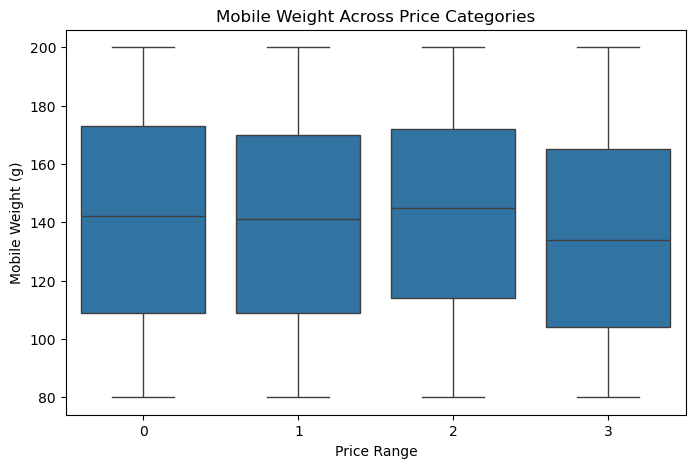

In [32]:
# BOX PLOT : Mobile Weight VS Price Range 

plt.figure(figsize=(8,5)) 

sns.boxplot( 
    data=df, 
    x=("price_range"),  
    y=("mobile_wt") 
) 

plt.title("Mobile Weight Across Price Categories") 
plt.xlabel("Price Range") 
plt.ylabel("Mobile Weight (g)") 

plt.show()   

### Observations
| Observation       | Finding                                                                                                                                   |
|-------------------|-------------------------------------------------------------------------------------------------------------------------------------------|
| **Median**        | The median varies slightly, increasing initially and then decreasing for the highest price range. There is no consistent upward trend.    |
| **Overlap**       | The distributions overlap heavily across all four price categories.                                                                       |
| **Outliers**      | No noticeable outliers are present.                                                                                                       |
| **Spread**        | The spread (IQR) is similar across all price categories, with only minor variations.                                                      |
| **Overall Trend** | Mobile weight does not show a clear relationship with the price range.                                                                    | 

### Business Interpretation
Mobile weight alone is not a strong indicator of a smartphone's price. Similar weight values are observed across all price categories, suggesting that other specifications such as RAM, processor, storage, and camera have a greater influence on pricing.
 
### Decision
- **Relationship:** Weak / No Clear Relationship
- **Confidence:** ⭐⭐☆☆☆
- **Decision:** Keep the feature for model training, as it may still contribute when combined with other features.


# Feature Analysis 6 : N Cores 

# Phase A — Understand the Feature 

In [33]:
df["n_cores"].describe() 

count    2000.000000
mean        4.520500
std         2.287837
min         1.000000
25%         3.000000
50%         4.000000
75%         7.000000
max         8.000000
Name: n_cores, dtype: float64

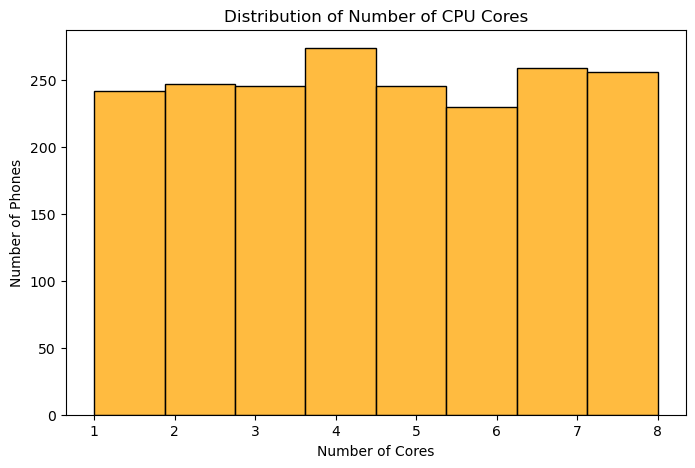

In [34]:
# HISTOGRAM : n core 

plt.figure(figsize=(8,5))

sns.histplot(
    df["n_cores"],
    bins=8,
    color="orange"
)

plt.title("Distribution of Number of CPU Cores")
plt.xlabel("Number of Cores")
plt.ylabel("Number of Phones")

plt.show() 

# Observations 
- The distribution is approximately uniform across most of the weight range.
- Mobile weights are spread throughout the entire range (80 g – 200 g).
- A noticeable concentration of phones is observed between **180 g and 200 g**.
- No obvious gaps or clusters are present in the distribution.
- The feature covers a wide range of mobile weights and appears suitable for model training. 

# Phase B — Compare with Target (N cores vs Price Range) 

## Business Question
Does n cores influence the mobile phone price range?

## Hypothesis
- Phones with more CPU cores are expected to belong to higher price ranges.
- The relationship is expected to be positive but moderate, as pricing also depends on RAM, internal memory, processor speed, battery, and other features.
- Some overlap between price categories is expected. 

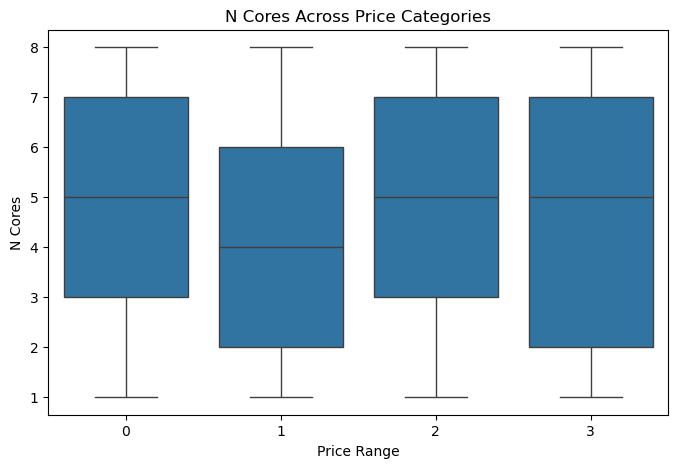

In [35]:
# BOX PLOT : N Cores VS Price Range 

plt.figure(figsize=(8,5)) 

sns.boxplot( 
    data=df, 
    x=("price_range"),  
    y=("n_cores") 
) 

plt.title("N Cores Across Price Categories") 
plt.xlabel("Price Range") 
plt.ylabel("N Cores") 

plt.show()    

# Observations 
| Observation         | Insight                                                                         |
| ------------------- | ------------------------------------------------------------------------------- |
| **Median Trend**    | The median first decreases, then increases, and finally remains stable.         |
| **Overlap**         | The price categories show **high overlap**.                                     |
| **Outliers**        | No outliers are observed.                                                       |
| **Spread (IQR)**    | The spread varies slightly, with the last price category having the widest box. |
| **Overall Pattern** | No clear increasing trend is observed across price ranges.                      |

# Business Interpretation
The number of CPU cores alone does not clearly distinguish the different price categories. 
Phones with both fewer and more cores appear across all price ranges, showing that the number of cores is only one of several factors affecting the price.

# Decision
N Cores has a moderate positive relationship with price_range. 
Therefore, it should be retained as a useful feature for model training.


## Feature Analysis 7 : Pixel Height 

# Phase A — Understand the Feature 

In [36]:
df["px_height"].describe() 

count    2000.000000
mean      645.108000
std       443.780811
min         0.000000
25%       282.750000
50%       564.000000
75%       947.250000
max      1960.000000
Name: px_height, dtype: float64

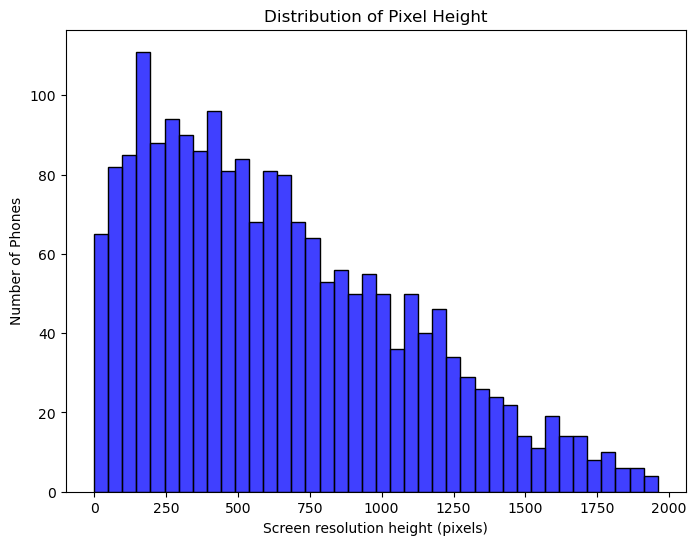

In [37]:
# HISTOGRAM : Pixel Height 

plt.figure(figsize=(8,6)) 

sns.histplot(
    df["px_height"], 
    bins=40,
    color="blue"
) 

plt.title("Distribution of Pixel Height")
plt.xlabel("Screen resolution height (pixels)") 
plt.ylabel("Number of Phones") 

plt.show()  

## Observations
- Mean is greater than the median, indicating a right-skewed distribution.
- Pixel height values are spread across the entire range.
- The histogram shows the highest concentration around lower pixel heights (approximately the fourth bin).
- The distribution gradually decreases as pixel height increases.
- The feature appears suitable for model training.

# Phase B — Compare with Target (Pixel Height vs Price Range)

## Business Question
Does pixel height influence the mobile phone price range?

## Hypothesis 
- Phones with higher pixel height are expected to belong to higher price ranges.
- The relationship is expected to be positive and strong, as higher screen resolution is commonly found in premium smartphones.
- Some overlap between price categories is still expected. 

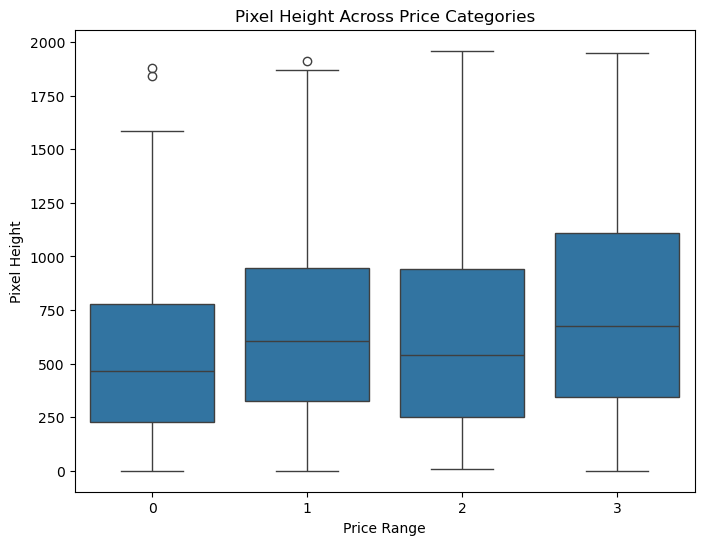

In [38]:
# BOX PLOT : Pixel Height 

plt.figure(figsize=(8,6)) 

sns.boxplot(
    data=df, 
    x=("price_range"), 
    y=("px_height")
) 

plt.title("Pixel Height Across Price Categories") 
plt.xlabel("Price Range") 
plt.ylabel("Pixel Height")

plt.show()  

# Observations 
| Observation         | Insight                                                                                          |
| ------------------- | ------------------------------------------------------------------------------------------------ |
| **Median Trend**    | The median increases from Price Range 0 to 1, decreases slightly at 2, and increases again at 3. |
| **Overlap**         | The price categories show moderate overlap.                                                      |
| **Outliers**        | A few outliers are present in Price Range 0 and 1.                                               |
| **Spread (IQR)**    | The spread varies slightly, with the last price category having a wider box.                     |
| **Overall Pattern** | Higher price categories generally tend to have higher pixel heights.                             |

# Business Interpretation 
Phones with higher pixel heights generally tend to belong to higher price categories. Although there is some overlap between the categories, pixel height shows a noticeable positive relationship with mobile phone price. 

# Decision 
Pixel Height has a strong positive relationship with price_range.
Therefore, it should be retained as an important feature for model training. 

## Feature Analysis 8: Pixel Width   

# Phase A — Understand the Feature 

In [39]:
df["px_width"]. describe() 

count    2000.000000
mean     1251.515500
std       432.199447
min       500.000000
25%       874.750000
50%      1247.000000
75%      1633.000000
max      1998.000000
Name: px_width, dtype: float64

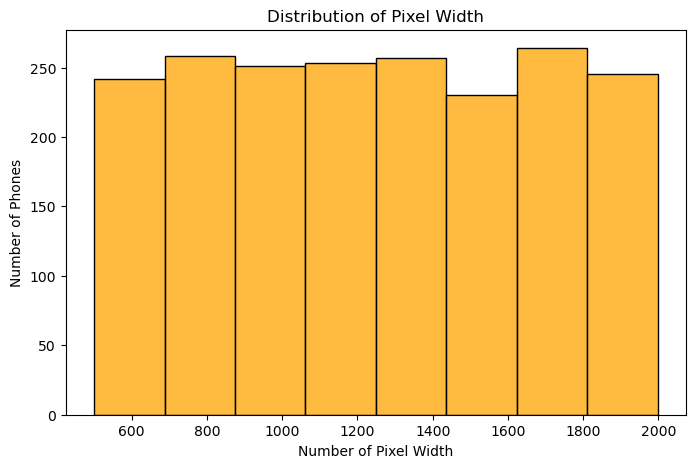

In [40]:
# HISTOGRAM : Pixel Width  

plt.figure(figsize=(8,5))

sns.histplot(
    df["px_width"],
    bins=8,
    color="orange"
)

plt.title("Distribution of Pixel Width")
plt.xlabel("Number of Pixel Width")
plt.ylabel("Number of Phones")

plt.show()  

# OBSERVATIONS: 
The distribution is approximately uniform.
Pixel width values are spread across the entire range (500–1998 pixels).
No single pixel width range clearly dominates the dataset.
No noticeable gaps or clusters are observed.

# Phase B — Compare with Target (Pixel Width vs Price Range) 

## Business Question
Does pixel width influence the mobile phone price range?

## Hypothesis 
- Phones with higher pixel width are expected to belong to higher price categories.
- The relationship is expected to be positive and strong because higher screen resolution is generally associated with premium smartphones.
- Some overlap between price categories is expected. 

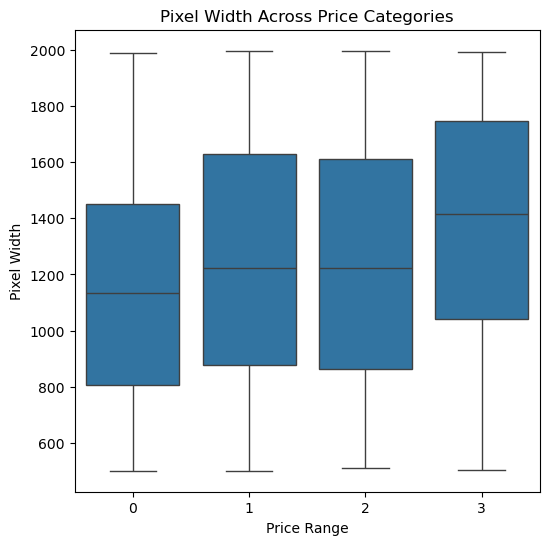

In [41]:
# BOX PLOT : Pixel Width VS Price Range 

plt.figure(figsize=(6,6))

sns.boxplot(
    data=df,
    x="price_range",
    y="px_width"
)

plt.title("Pixel Width Across Price Categories")
plt.xlabel("Price Range")
plt.ylabel("Pixel Width")

plt.show() 

## Observations
| Observation          | Insight                                                                                                        |
|----------------------|----------------------------------------------------------------------------------------------------------------|
| **Median Trend**     | The median generally increases across the price categories.                                                    |
| **Overlap**          | The price categories show **moderate overlap**.                                                                |
| **Outliers**         | No outliers are observed.                                                                                      |
| **Spread (IQR)**     | The spread is fairly similar across the categories, with the last price category showing a slightly wider box. |
| **Overall Pattern**  | An overall increasing trend is observed across the price categories.                                           | 

## Business Interpretation
Higher-priced phones generally tend to have greater pixel width. However, the overlap between price categories indicates that pixel width alone is not sufficient to distinguish mobile prices and works better when combined with other display features.

## Decision
Pixel Width has a moderate positive relationship with `price_range`.
Therefore, it should be retained as an important feature for model training.

## Feature Analysis 9: Talk Time

# Phase A — Understand the Feature 

In [42]:
df["talk_time"]. describe() 

count    2000.000000
mean       11.011000
std         5.463955
min         2.000000
25%         6.000000
50%        11.000000
75%        16.000000
max        20.000000
Name: talk_time, dtype: float64

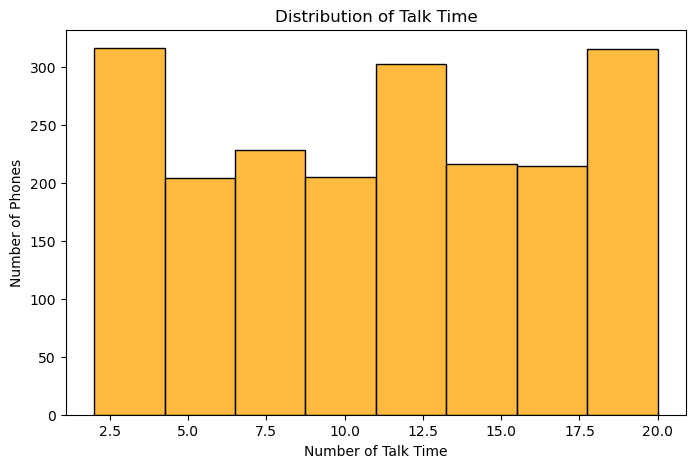

In [43]:
# HISTOGRAM : Talk Time

plt.figure(figsize=(8,5))

sns.histplot(
    df["talk_time"],
    bins=8,
    color="orange"
)

plt.title("Distribution of Talk Time")
plt.xlabel("Number of Talk Time")
plt.ylabel("Number of Phones")

plt.show()  

## Observations
- The distribution is approximately **uniform**.
- Talk time values are spread across the entire range (2–20 hours).
- Higher frequencies are observed around **2–4 hours**, **11–13 hours**, and **18–20 hours**.
- No noticeable gaps are observed in the distribution.

# Phase B — Compare with Target (Pixel Width vs Price Range) 

## Business Question
Does longer battery life automatically mean an expensive phone? 

## Hypothesis
- Talk time is expected to have a weak to moderate positive relationship with price.
- Phones with longer talk time may belong to higher price categories.
- Considerable overlap between price categories is expected.

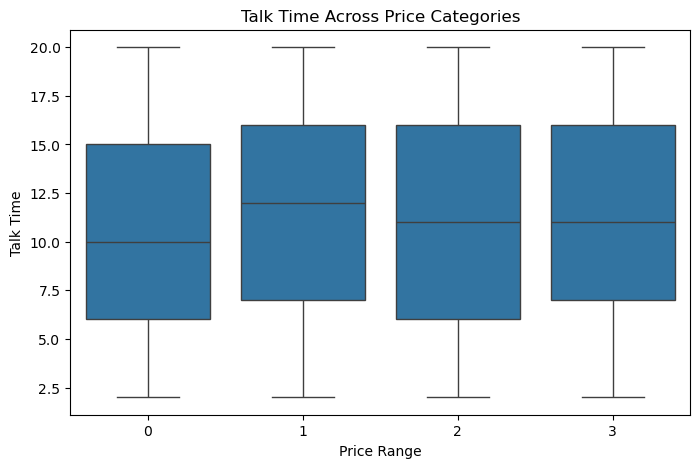

In [44]:
# BOX PLOT : Talk Time VS Price Range 

plt.figure(figsize=(8,5)) 

sns.boxplot( 
    data=df, 
    x=("price_range"),  
    y=("talk_time") 
) 

plt.title("Talk Time Across Price Categories") 
plt.xlabel("Price Range") 
plt.ylabel("Talk Time") 

plt.show()     

# Observation 
| Observation         | Insight                                                                                 |
|---------------------|-----------------------------------------------------------------------------------------|
| **Median Trend**    | The median first increases and then remains nearly stable across the price categories.  |
| **Overlap**         | The price categories show **high overlap**.                                             |
| **Outliers**        | No outliers are observed.                                                               |
| **Spread (IQR)**    | The spread is similar across all price categories.                                      |
| **Overall Pattern** | No clear increasing trend is observed across the price categories.                      | 

# Business Interpretation 
Talk time alone does not clearly distinguish the different price categories.
Phones with both shorter and longer talk times appear across all price ranges, indicating that talk time is only one of several factors affecting the price. 

# Decision 
Talk Time has a weak to moderate positive relationship with `price_range`.
Therefore, it should be retained as a useful feature for model training. 

## Feature Analysis 10 :  Screen Height

# Phase A — Understand the Feature 

In [45]:
df["sc_h"]. describe() 

count    2000.000000
mean       12.306500
std         4.213245
min         5.000000
25%         9.000000
50%        12.000000
75%        16.000000
max        19.000000
Name: sc_h, dtype: float64

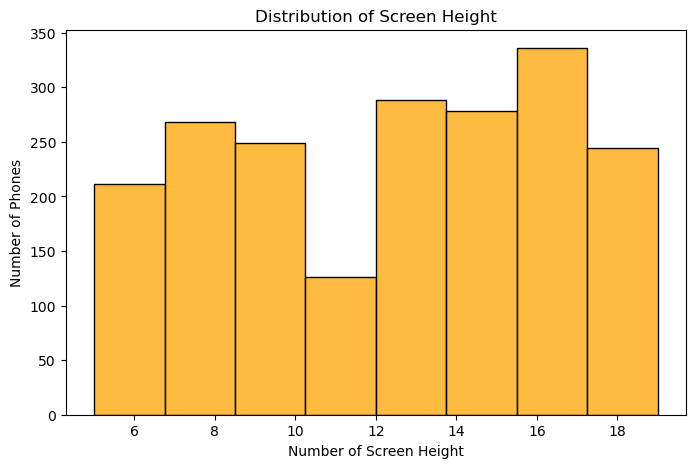

In [46]:
# HISTOGRAM : 

plt.figure(figsize=(8,5))

sns.histplot(
    df["sc_h"],
    bins=8,
    color="orange"
)

plt.title("Distribution of Screen Height")
plt.xlabel("Number of Screen Height")
plt.ylabel("Number of Phones")

plt.show()   

# OBSERVATIONS: 
- The distribution is roughly uniform across the range.
- The data is spread throughout the entire range.
- A higher concentration of phones is observed around screen heights of 16–17 while lower around 10-12. 
- No major gaps or isolated clusters are observed. 

# Phase B — Compare with Target (Screen Height vs Price Range) 

## Business Question
Does screen height influence the mobile phone price range? 

## Hypothesis 
Screen height is expected to have a weak to moderate positive relationship with price.
Phones with larger screen heights may belong to higher price categories.
Some overlap between price categories is expected because screen height alone does not determine the price. 

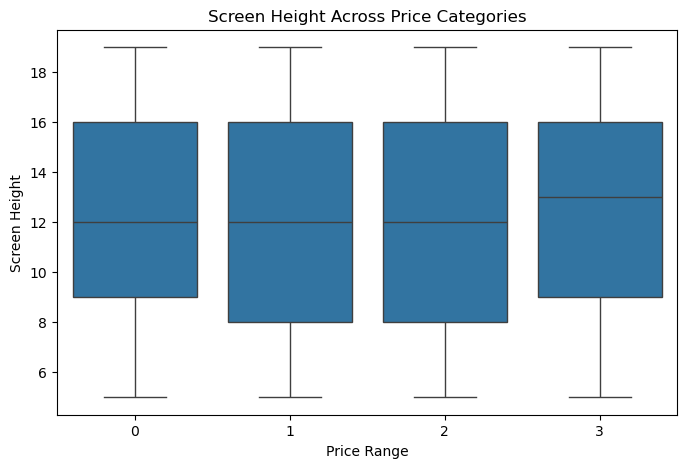

In [47]:
# BOX PLOT : Screen Height VS Price Range 

plt.figure(figsize=(8,5)) 

sns.boxplot( 
    data=df, 
    x=("price_range"),  
    y=("sc_h") 
) 

plt.title("Screen Height Across Price Categories") 
plt.xlabel("Price Range") 
plt.ylabel("Screen Height") 

plt.show()      

# OBSERVATIONS 
| Observation         | Insight                                                                                         |
| ------------------- | ----------------------------------------------------------------------------------------------- |
| **Median Trend**    | The median remains almost the same initially and increases slightly in the last price category. |
| **Overlap**         | The price categories show **high overlap**.                                                     |
| **Outliers**        | No outliers are observed.                                                                       |
| **Spread (IQR)**    | The spread is similar across all price categories.                                              |
| **Overall Pattern** | No clear increasing trend is observed across price ranges.                                      |

# Business Interpretation 
Screen height alone does not clearly distinguish the different price categories. Phones with similar screen heights appear across all price ranges, indicating that screen height is only one of several factors affecting the price.    

# Decision 
Screen height has a weak to moderate positive relationship with price_range.
Therefore, it should be retained as a useful feature for model training.  

## Feature Analysis 11: Screen Width

# Phase A — Understand the Feature 

In [48]:
df["sc_w"]. describe()  

count    2000.000000
mean        5.767000
std         4.356398
min         0.000000
25%         2.000000
50%         5.000000
75%         9.000000
max        18.000000
Name: sc_w, dtype: float64

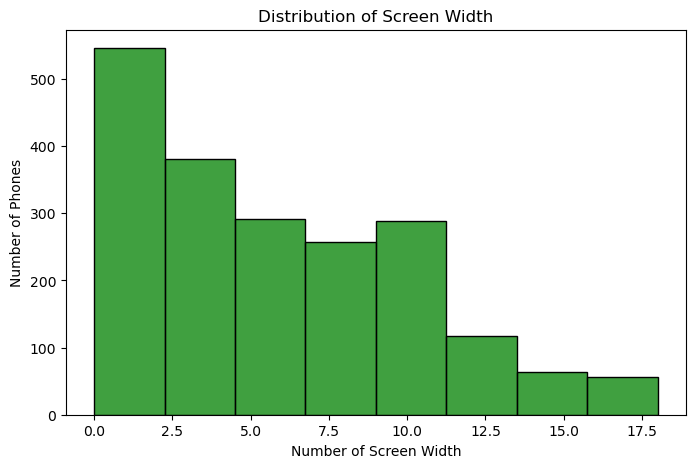

In [49]:
# HISTOGRAM : Screen Width

plt.figure(figsize=(8,5))

sns.histplot(
    df["sc_w"],
    bins=8,
    color="green"
)

plt.title("Distribution of Screen Width")
plt.xlabel("Number of Screen Width")
plt.ylabel("Number of Phones")

plt.show()   

# OBSERVATIONS:  
- The distribution is right-skewed.
- The data is spread throughout the entire range.
- The highest concentration of phones is observed at lower screen width values (around 0–2).
- The frequency gradually decreases as screen width increases.

# Phase B — Compare with Target (Screen Width vs Price Range) 

## Business Question
Does screen width influence the mobile phone price range?

### Hypothesis 
Screen width is expected to have a weak to moderate positive relationship with price.
Phones with larger screen widths may belong to higher price categories.
Some overlap between price categories is expected because screen width alone does not determine the price. 

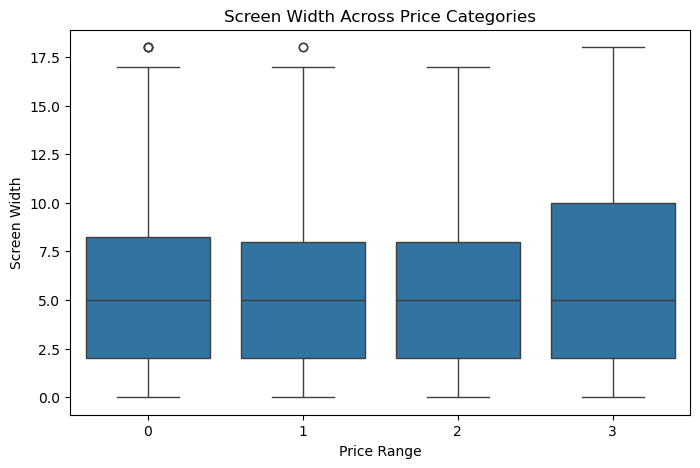

In [50]:
# BOX PLOT : Screen Width VS Price Range 

plt.figure(figsize=(8,5)) 

sns.boxplot( 
    data=df, 
    x=("price_range"),  
    y=("sc_w") 
) 

plt.title("Screen Width Across Price Categories") 
plt.xlabel("Price Range") 
plt.ylabel("Screen Width") 

plt.show()      

# OBSERVATION 
| Observation         | Insight                                                                         |
| ------------------- | ------------------------------------------------------------------------------- |
| **Median Trend**    | The median remains almost the same across all price categories.                 |
| **Overlap**         | The price categories show **high overlap**.                                     |
| **Outliers**        | A few outliers are observed in price categories **0** and **1**.                |
| **Spread (IQR)**    | The spread is similar initially and slightly larger in the last price category. |
| **Overall Pattern** | No clear increasing trend is observed across price ranges.                      |

# Business Interpretation
Screen width alone does not clearly distinguish the different price categories. Phones with similar screen widths appear across all price ranges, indicating that screen width is only one of several factors affecting the price. 

# Decision
Screen width has a weak to moderate positive relationship with price_range.
Therefore, it should be retained as a useful feature for model training.  

## Feature Analysis 12: Primary Camera

# Phase A — Understand the Feature 

In [51]:
df["pc"]. describe()  

count    2000.000000
mean        9.916500
std         6.064315
min         0.000000
25%         5.000000
50%        10.000000
75%        15.000000
max        20.000000
Name: pc, dtype: float64

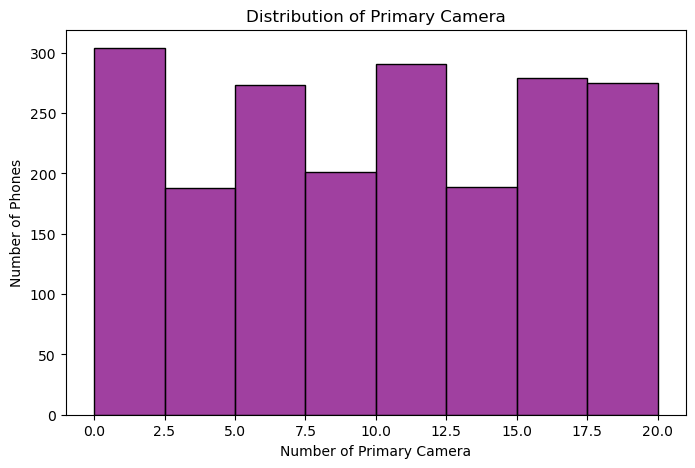

In [52]:
# HISTOGRAM : Primary Camera 

plt.figure(figsize=(8,5))

sns.histplot(
    df["pc"],
    bins=8,
    color="purple"
)

plt.title("Distribution of Primary Camera")
plt.xlabel("Number of Primary Camera") 
plt.ylabel("Number of Phones")

plt.show()     

# OBSERVATIONS:  
- The values are spread across the entire range (0–20 MP).
- Three bins have comparatively lower frequencies, while the remaining bins have higher frequencies.
- No clear skewness is observed. No single range dominates the distribution.  

# Phase B — Compare with Target (Primary Camera vs Price Range) 

# Business Question
Does the primary camera resolution influence the mobile phone price range?

# Hypothesis
Phones with higher primary camera resolution are expected to belong to higher price categories.
This follows the same simple, uniform pattern you've been using for all your EDA features. 

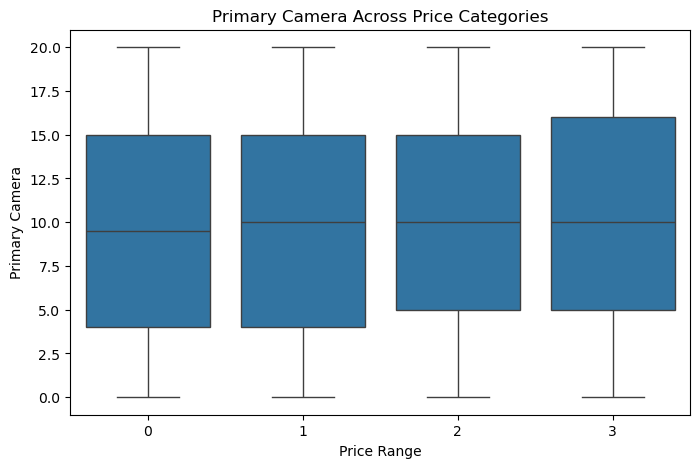

In [53]:
# BOX PLOT : Primary Camera VS Price Range 

plt.figure(figsize=(8,5)) 

sns.boxplot( 
    data=df,  
    x=("price_range"),  
    y=("pc") 
) 

plt.title("Primary Camera Across Price Categories") 
plt.xlabel("Price Range") 
plt.ylabel("Primary Camera") 

plt.show()      

# OBSERVATIONS 
| Observation         | Insight                                                                                           |
| ------------------- | ------------------------------------------------------------------------------------------------- |
| **Median Trend**    | The median remains nearly constant across all price categories.                                   |
| **Overlap**         | The price categories show **high overlap**.                                                       |
| **Outliers**        | No outliers are observed.                                                                         |
| **Spread (IQR)**    | The spread is similar across all categories, with the last category showing a slightly wider box. |
| **Overall Pattern** | No clear increasing trend is observed across price ranges.                                        |

# Business Interpretation 
Primary camera resolution alone does not clearly distinguish low-priced phones from high-priced phones. Similar primary camera values appear across all price categories, indicating that price depends on multiple specifications rather than camera resolution alone.

# Decision
Primary Camera has a weak to moderate positive relationship with price_range.
Therefore, it should be retained as a useful feature for model training. 

## Feature Analysis 13 : Front Camera 

# Phase A — Understand the Feature 

In [54]:
df["fc"]. describe()  

count    2000.000000
mean        4.309500
std         4.341444
min         0.000000
25%         1.000000
50%         3.000000
75%         7.000000
max        19.000000
Name: fc, dtype: float64

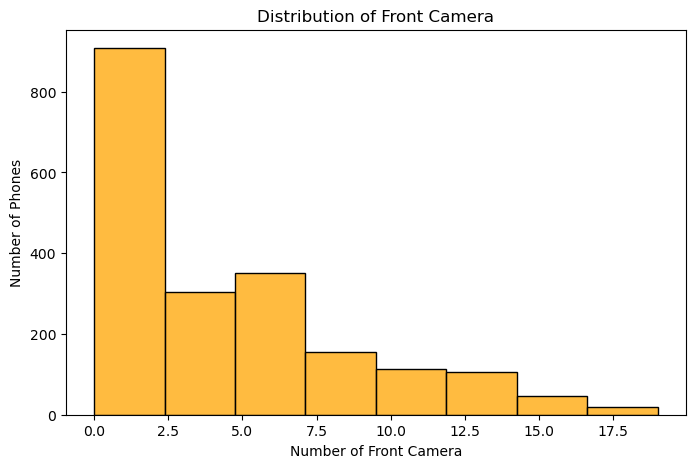

In [55]:
# HISTOGRAM : Front Camera

plt.figure(figsize=(8,5))

sns.histplot(
    df["fc"],
    bins=8,
    color="orange"
)

plt.title("Distribution of Front Camera")
plt.xlabel("Number of Front Camera")
plt.ylabel("Number of Phones")

plt.show()     

# OBSERVATIONS: 
- The distribution is right-skewed.
- Most phones have lower front camera values (0–7 MP).
- The frequency decreases as the front camera value increases.
- Very few phones have high front camera values.

# Phase B — Compare with Target (Front Camera vs Price Range) 

## Business Question
Does the front camera resolution influence the mobile phone price range? 

## Hypothesis 
Phones with higher front camera resolution are expected to belong to higher price categories. 

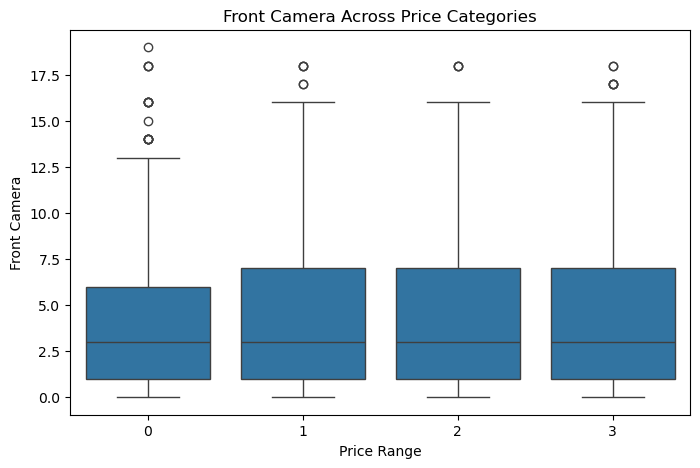

In [56]:
# BOX PLOT : Front Camera VS Price Range 

plt.figure(figsize=(8,5)) 

sns.boxplot( 
    data=df, 
    x=("price_range"),  
    y=("fc")  
)  

plt.title("Front Camera Across Price Categories") 
plt.xlabel("Price Range") 
plt.ylabel("Front Camera") 

plt.show()     

# Observations 
| Observation         | Insight                                                         |
| ------------------- | --------------------------------------------------------------- |
| **Median Trend**    | The median remains nearly constant across all price categories. |
| **Overlap**         | The price categories show **high overlap**.                     |
| **Outliers**        | Outliers are present in all four price categories.              |
| **Spread (IQR)**    | The spread is similar across all categories.                    |
| **Overall Pattern** | No clear increasing trend is observed across price ranges.      |

# Business Interpretation 
Front camera resolution alone does not clearly distinguish low-priced phones from high-priced phones. Similar front camera values appear across all price categories, indicating that price depends on multiple specifications rather than front camera resolution alone. 

# Decision 
Front Camera has a weak to moderate positive relationship with price_range.
Therefore, it should be retained as a useful feature for model training.   

## Feature Analysis 14 : Mobile Depth  

# Phase A — Understand the Feature  

In [57]:
df["m_dep"]. describe()     

count    2000.000000
mean        0.501750
std         0.288416
min         0.100000
25%         0.200000
50%         0.500000
75%         0.800000
max         1.000000
Name: m_dep, dtype: float64

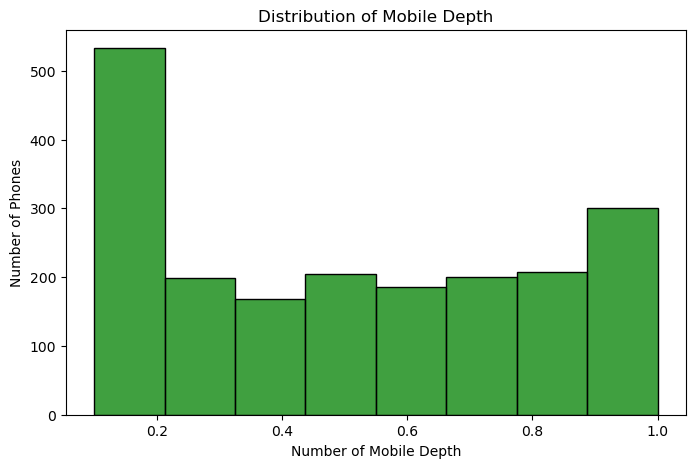

In [58]:
# HISTOGRAM : Mobile Depth

plt.figure(figsize=(8,5))

sns.histplot(
    df["m_dep"], 
    bins=8,
    color="green"
)

plt.title("Distribution of Mobile Depth")
plt.xlabel("Number of Mobile Depth")
plt.ylabel("Number of Phones")

plt.show()      

# OBSERVATIONS: 
- The values are spread across the entire range (0.1–1.0).
- The first bin has the highest frequency.
- The middle bins have comparatively lower frequencies.
- The last bin also shows a relatively higher frequency. 

# Phase B — Compare with Target (Mobile Depth vs Price Range) 

## Business Question
Does mobile depth influence the mobile phone price range?

### Hypothesis
Phones with different mobile depth may belong to different price categories. 

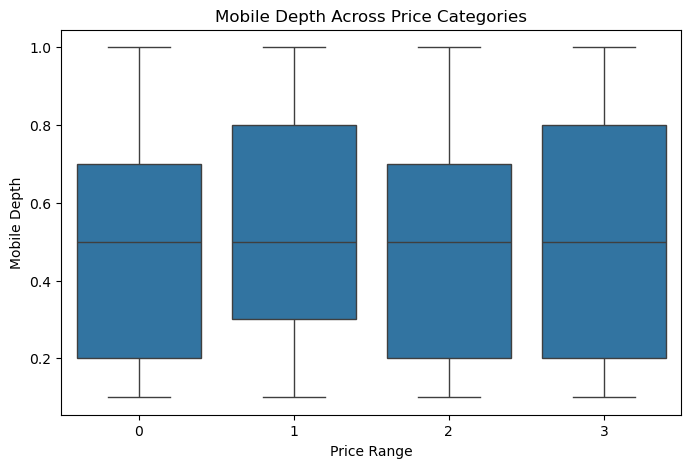

In [59]:
# BOX PLOT : Mobile Depth VS Price Range 

plt.figure(figsize=(8,5)) 

sns.boxplot( 
    data=df, 
    x=("price_range"),  
    y=("m_dep")  
)  

plt.title("Mobile Depth Across Price Categories") 
plt.xlabel("Price Range") 
plt.ylabel("Mobile Depth") 

plt.show()       

# Observations 
| Observation         | Insight                                                                                            |
| ------------------- | -------------------------------------------------------------------------------------------------- |
| **Median Trend**    | The median remains constant across all price categories.                                           |
| **Overlap**         | The price categories show **high overlap**.                                                        |
| **Outliers**        | No outliers are observed.                                                                          |
| **Spread (IQR)**    | The spread is similar across all categories, with categories 1 and 3 showing slightly wider boxes. |
| **Overall Pattern** | No clear increasing trend is observed across price ranges.                                         | 

# Business Interpretation 
Mobile depth does not clearly distinguish low-priced phones from high-priced phones. Similar mobile depth values appear across all price categories, indicating that thickness alone has little influence on pricing. 

# Decision
Mobile Depth has a weak relationship with price_range.
Therefore, it should be retained as a useful feature for model training.  

## BINARY Feature Analysis 15 : Bluetooth 

# Phase A — Understand the Feature  

In [60]:
df["blue"]. describe()    

count    2000.0000
mean        0.4950
std         0.5001
min         0.0000
25%         0.0000
50%         0.0000
75%         1.0000
max         1.0000
Name: blue, dtype: float64

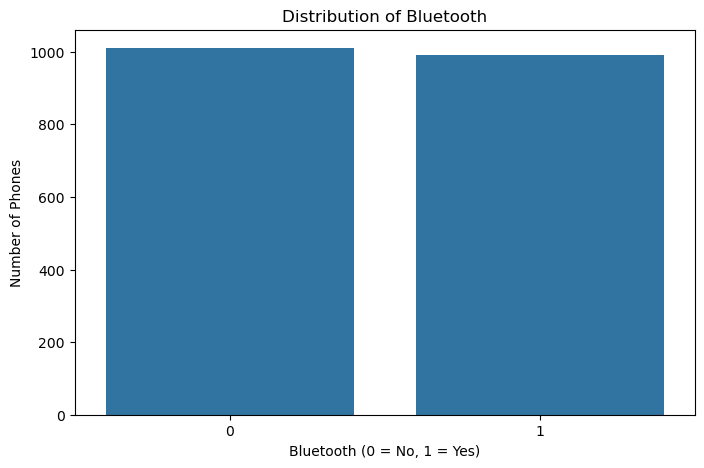

In [61]:
# COUNT PLOT : Bluetooth

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="blue"
)

plt.title("Distribution of Bluetooth")
plt.xlabel("Bluetooth (0 = No, 1 = Yes)")
plt.ylabel("Number of Phones")

plt.show()  

# OBSERVATIONS:   
| Observation       | Insight                                                                            |
| ----------------- | ---------------------------------------------------------------------------------- |
| **Class Balance** | The number of phones with Bluetooth (1) and without Bluetooth (0) is almost equal. |
| **Distribution**  | The feature is well balanced, with no class dominating the dataset.                |
| **Data Quality**  | No missing or unexpected categories are observed (only 0 and 1).                   | 

# Phase B — Compare with Target (Bluetooth vs Price Range) 

# Business Question
Does the presence of Bluetooth influence the mobile phone price range?

# Hypothesis
Phones with Bluetooth may belong to higher price categories more often than phones without Bluetooth.    

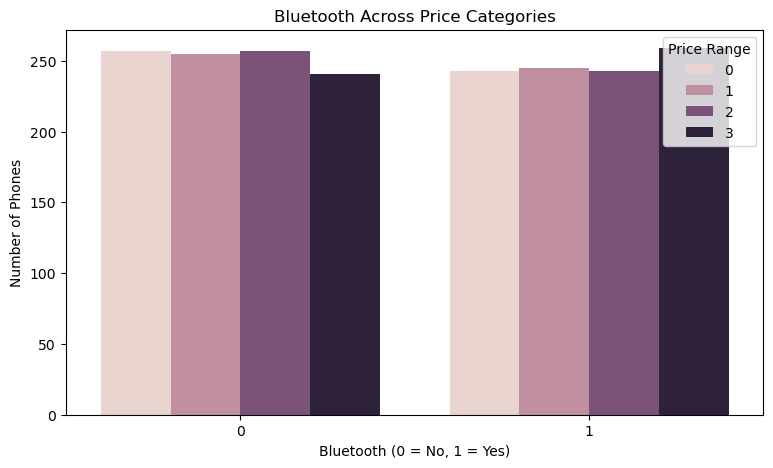

In [62]:
# COUNT PLOT : Bluetooth vs Price Range

plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x="blue",
    hue="price_range"
)

plt.title("Bluetooth Across Price Categories")
plt.xlabel("Bluetooth (0 = No, 1 = Yes)")
plt.ylabel("Number of Phones")
plt.legend(title="Price Range")

plt.show()   

# Observations
| Observation            | Insight                                                                     |
| ---------------------- | --------------------------------------------------------------------------- |
| **Price Distribution** | All four price ranges appear in both Bluetooth categories.                  |
| **Comparison**         | The bar heights are very similar across price ranges.                       |
| **Pattern**            | No strong trend between Bluetooth availability and price range is observed. |

# Business Interpretation
Bluetooth is available across both low-priced and high-priced phones. It does not appear to be a distinguishing feature for predicting price.

# Decision
Bluetooth has a weak relationship with price_range. It can be retained, but it is unlikely to be a highly important feature.   

## BINARY Feature Analysis 16 : WiFi

# Phase A — Understand the Feature  

In [63]:
df["wifi"]. describe()     

count    2000.000000
mean        0.507000
std         0.500076
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: wifi, dtype: float64

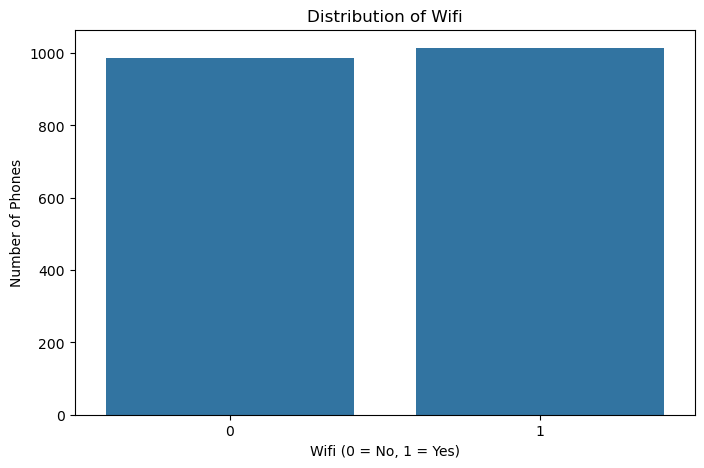

In [64]:
# COUNT PLOT : Wifi 

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="wifi"
)

plt.title("Distribution of Wifi")
plt.xlabel("Wifi (0 = No, 1 = Yes)")
plt.ylabel("Number of Phones")

plt.show()   

# OBSERVATIONS:   
| Observation       | Insight                                                                               |
| ----------------- | ------------------------------------------------------------------------------------- |
| **Class Balance** | The number of phones with WiFi (1) and without WiFi (0) is almost equal.              |
| **Distribution**  | Both categories are nearly equally represented, indicating a balanced binary feature. |
| **Data Quality**  | Only valid categories (0 and 1) are present, with no missing or unexpected values.    | 

# Phase B — Compare with Target (Wifi vs Price Range)  

## Business Question
Does the availability of WiFi influence the mobile phone price range?

### Hypothesis
Phones with WiFi may belong to higher price categories more frequently than phones without WiFi.     

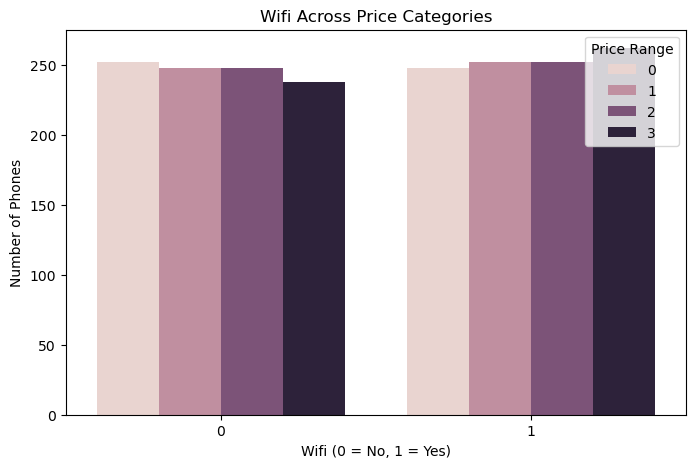

In [65]:
# COUNT PLOT : Wifi vs Price Range

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="wifi",
    hue="price_range"
)

plt.title("Wifi Across Price Categories")
plt.xlabel("Wifi (0 = No, 1 = Yes)")
plt.ylabel("Number of Phones")
plt.legend(title="Price Range")

plt.show()   

# Observations 
| Observation            | Insight                                                                           |
| ---------------------- | --------------------------------------------------------------------------------- |
| **Price Distribution** | All four price ranges are present for both WiFi = 0 and WiFi = 1.                 |
| **Comparison**         | The bar heights across all price ranges are nearly identical for both categories. |
| **Pattern**            | No clear relationship between WiFi availability and price range is observed.      |

# Business Interpretation 
WiFi is available across both low-priced and high-priced phones. It does not appear to be a key factor in distinguishing different price categories. 

# Decision
WiFi has a weak relationship with price_range. Therefore, it should be retained as a feature, but it is unlikely to have high predictive importance.  

## BINARY Feature Analysis 17 : 3G 

# Phase A — Understand the Feature  

In [66]:
df["three_g"]. describe()    

count    2000.000000
mean        0.761500
std         0.426273
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: three_g, dtype: float64

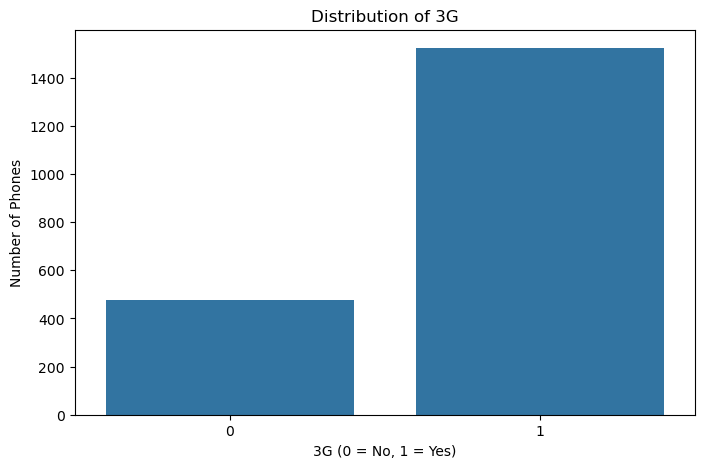

In [67]:
# COUNT PLOT : 3G

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="three_g"
)

plt.title("Distribution of 3G")
plt.xlabel("3G (0 = No, 1 = Yes)")
plt.ylabel("Number of Phones")

plt.show()  

# OBSERVATIONS:   
| Observation   | Insight                                                                                          |
| ------------- | ------------------------------------------------------------------------------------------------ |
| Class Balance | Most phones support **3G (1)**, while a smaller proportion do **not support 3G (0)**.            |
| Distribution  | The feature is **imbalanced**, with approximately three-fourths of the phones having 3G support. |
| Data Quality  | Only valid categories (**0** and **1**) are present, with no missing or unexpected values.       |  

# Phase B — Compare with Target (Bluetooth vs Price Range) 

# Business Question
Does the availability of 3G influence the mobile phone price range? 

# Hypothesis
Phones with 3G support may belong to higher price categories more frequently than phones without 3G support.    

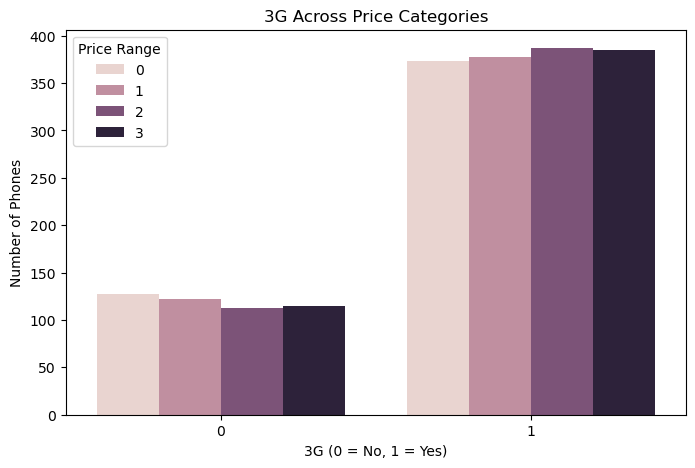

In [68]:
# COUNT PLOT : 3G vs Price Range

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="three_g",
    hue="price_range"
)

plt.title("3G Across Price Categories")
plt.xlabel("3G (0 = No, 1 = Yes)")
plt.ylabel("Number of Phones")
plt.legend(title="Price Range")

plt.show() 

# Observation 
| Observation        | Insight                                                                                                                                                     |
| ------------------ | ----------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Price Distribution | All four price ranges are present for both **3G = 0** and **3G = 1**.                                                                                       |
| Comparison         | Phones with **3G support (1)** are more common across every price range than phones without 3G.                                                             |
| Pattern            | Although 3G-supported phones are more numerous, the distribution across price ranges is fairly similar, indicating no strong relationship with price range. |

# Business Interpretation 
3G support is a common feature across mobile phones in the dataset. While phones with 3G are more frequent, it does not clearly distinguish lower-priced phones from higher-priced phones. 

# Decision
3G has a weak to moderate relationship with price_range. Therefore, it should be retained as a feature, but it is unlikely to have high predictive importance on its own. 

## POINTER : 
Although the number of phones with 3G support is much higher than those without 3G support, both groups contain phones from all price ranges. Therefore, 3G support alone does not clearly distinguish the price category.  

## BINARY Feature Analysis 18 : 4G 

# Phase A — Understand the Feature   

In [69]:
df["four_g"]. describe()    

count    2000.000000
mean        0.521500
std         0.499662
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: four_g, dtype: float64

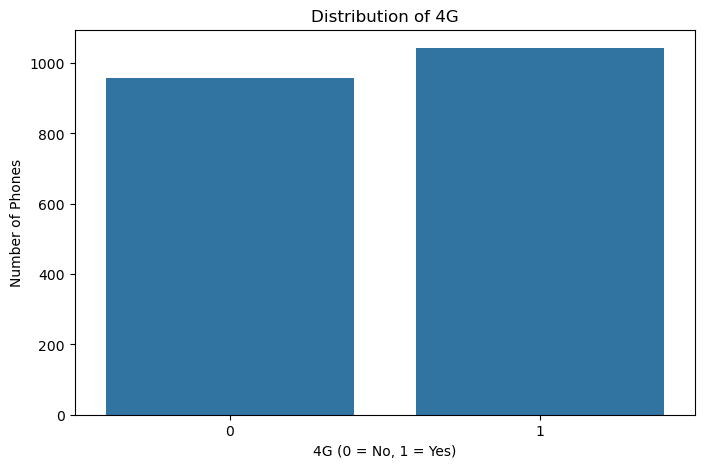

In [70]:
# COUNT PLOT : 4G

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="four_g"
)

plt.title("Distribution of 4G")
plt.xlabel("4G (0 = No, 1 = Yes)")
plt.ylabel("Number of Phones")

plt.show()   

# OBSERVATIONS:   
| Observation   | Insight                                                                                                               |
| ------------- | --------------------------------------------------------------------------------------------------------------------- |
| Class Balance | The number of phones with **4G (1)** and without **4G (0)** is nearly equal, with slightly more phones supporting 4G. |
| Distribution  | Both categories are well represented, making this a fairly balanced binary feature.                                   |
| Data Quality  | Only valid categories (0 and 1) are present, with no missing or unexpected values.                                    | 

# Phase B — Compare with Target (Bluetooth vs Price Range) 

## Business Question
Does the availability of 4G influence the mobile phone price range?

### Hypothesis
Phones with 4G support are more likely to belong to higher price categories than phones without 4G support.  

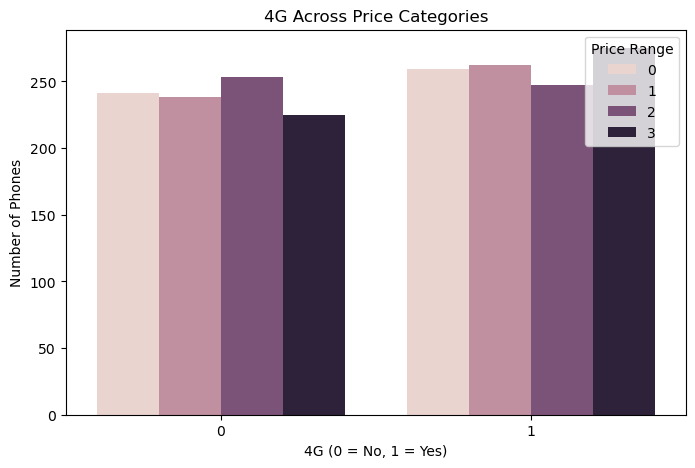

In [71]:
# COUNT PLOT : 4G vs Price Range

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="four_g",
    hue="price_range"
)

plt.title("4G Across Price Categories")
plt.xlabel("4G (0 = No, 1 = Yes)")
plt.ylabel("Number of Phones")
plt.legend(title="Price Range")

plt.show()   

# Observations 
| Observation        | Insight                                                                                                                  |
| ------------------ | ------------------------------------------------------------------------------------------------------------------------ |
| Price Distribution | All four price ranges are present for both **4G = 0** and **4G = 1**.                                                    |
| Comparison         | Phones with **4G support** show a slightly higher presence in the higher price categories compared to phones without 4G. |
| Pattern            | A slight positive relationship exists between 4G support and price range, although the separation is not very strong.    |

## Business Interpretation
4G support is available across all price categories, but it appears slightly more common in higher-priced phones. This suggests that 4G may contribute to the mobile phone's price, although it is not the sole factor determining the price range.

### Decision
4G has a moderate positive relationship with price_range. Therefore, it should be retained as an important feature for model training. 

# POINTER: 
## For 4G = 0:
- Price Range 2 has the highest count.
- Price Range 3 has the lowest count.
## For 4G = 1:
- Price Range 0 and 1 are still present.
- Price Range 3 increases compared with the 4G = 0 group.
Unlike WiFi and Bluetooth, the bars are not almost identical. The differences are small, but there is a slight shift. 

## BINARY Feature Analysis 19 : Dual SIM   

# Phase A — Understand the Feature   

In [72]:
df.shape 

(2000, 21)

In [73]:
df["dual_sim"].describe()  

count    2000.000000
mean        0.509500
std         0.500035
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: dual_sim, dtype: float64

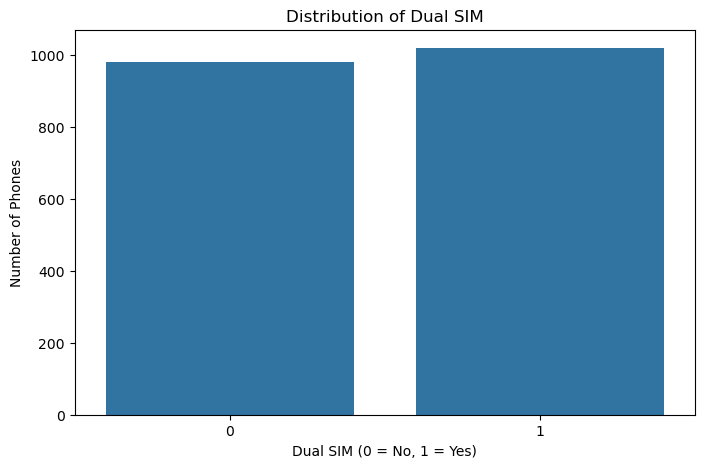

In [74]:
# COUNT PLOT : Dual SIM 

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="dual_sim"
)

plt.title("Distribution of Dual SIM")
plt.xlabel("Dual SIM (0 = No, 1 = Yes)")
plt.ylabel("Number of Phones")

plt.show()   

# OBSERVATION  
| Observation   | Insight                                                                                                                                 |
| ------------- | --------------------------------------------------------------------------------------------------------------------------------------- |
| Class Balance | The number of phones with **Dual SIM (1)** and without **Dual SIM (0)** is almost equal, with slightly more phones supporting Dual SIM. |
| Distribution  | Both categories are nearly equally represented, indicating a balanced binary feature.                                                   |
| Data Quality  | Only valid categories (0 and 1) are present, with no missing or unexpected values.                                                      | 

# Phase B — Compare with Target (Dual SIM vs Price Range) 

## Business Question
Does the availability of Dual SIM influence the mobile phone price range?

### Hypothesis
Phones with Dual SIM support may belong to higher price categories more frequently than phones without Dual SIM support.   

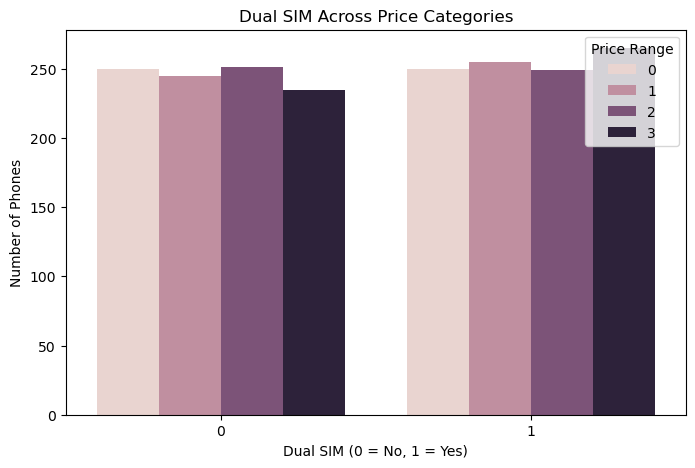

In [75]:
# COUNT PLOT : Dual SIM vs Price Range

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="dual_sim",
    hue="price_range"
)

plt.title("Dual SIM Across Price Categories")
plt.xlabel("Dual SIM (0 = No, 1 = Yes)")
plt.ylabel("Number of Phones")
plt.legend(title="Price Range")

plt.show()     

# Observations 
| Observation        | Insight                                                                            |
| ------------------ | ---------------------------------------------------------------------------------- |
| Price Distribution | All four price ranges are present for both **Dual SIM = 0** and **Dual SIM = 1**.  |
| Comparison         | The bar heights across all four price ranges are very similar for both categories. |
| Pattern            | No clear relationship between Dual SIM availability and price range is observed.   |

## Business Interpretation
Dual SIM support is available across both low-priced and high-priced phones. The distribution of price categories remains almost the same whether a phone has Dual SIM or not. This indicates that Dual SIM alone does not significantly influence the mobile phone's price.

### Decision
Dual SIM has a weak relationship with price_range. Therefore, it should be retained as a feature, but it is unlikely to have high predictive importance. 

## BINARY Feature Analysis 20 : Touch Screen 

# Phase A — Understand the Feature  

In [76]:
df["touch_screen"].describe()  

count    2000.000000
mean        0.503000
std         0.500116
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: touch_screen, dtype: float64

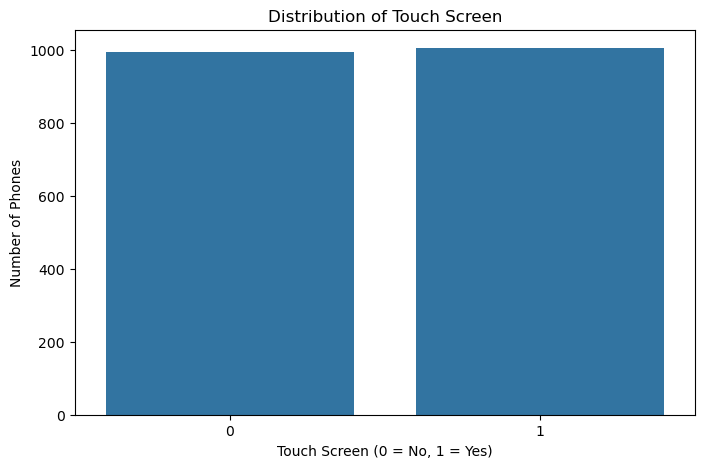

In [77]:
# COUNT PLOT : Touch Screen

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="touch_screen"
)

plt.title("Distribution of Touch Screen")
plt.xlabel("Touch Screen (0 = No, 1 = Yes)")
plt.ylabel("Number of Phones")

plt.show()     

# OBSERVATION    
| Observation   | Insight                                                                                                                                              |
| ------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------- |
| Class Balance | The number of phones with **Touch Screen (1)** and without **Touch Screen (0)** is almost equal, with slightly more phones supporting touch screens. |
| Distribution  | Both categories are nearly equally represented, indicating a balanced binary feature.                                                                |
| Data Quality  | Only valid categories (0 and 1) are present, with no missing or unexpected values.                                                                   | 

# Phase B — Compare with Target (Touch Screen vs Price Range) 

## Business Question
Does the availability of a touch screen influence the mobile phone price range?

### Hypothesis
Phones with touch screens may belong to higher price categories more frequently than phones without touch screens.  

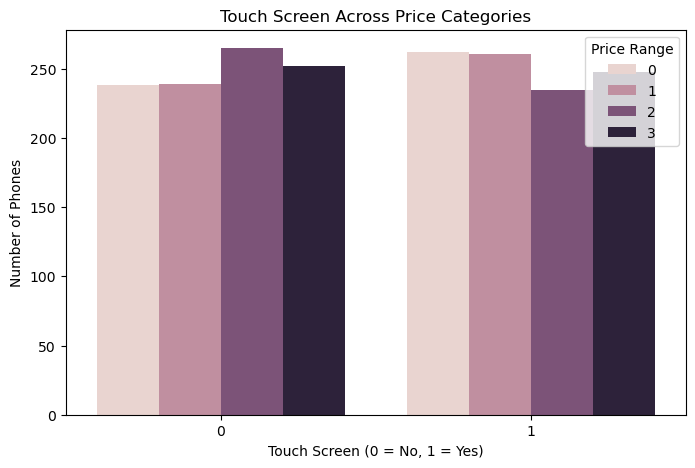

In [78]:
# COUNT PLOT : Touch Screen vs Price Range

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="touch_screen",
    hue="price_range"
)

plt.title("Touch Screen Across Price Categories")
plt.xlabel("Touch Screen (0 = No, 1 = Yes)")
plt.ylabel("Number of Phones")
plt.legend(title="Price Range")

plt.show()     

# Observations 
| Observation        | Insight                                                                                   |
| ------------------ | ----------------------------------------------------------------------------------------- |
| Price Distribution | All four price ranges are present for both **Touch Screen = 0** and **Touch Screen = 1**. |
| Comparison         | The bar heights across all four price ranges are very similar for both categories.        |
| Pattern            | No clear relationship between touch screen availability and price range is observed.      |

## Business Interpretation
Touch screen support is available across both low-priced and high-priced phones. The distribution of price categories remains almost the same whether a phone has a touch screen or not. This suggests that touch screen availability alone does not significantly influence the mobile phone's price.

### Decision
Touch Screen has a weak relationship with price_range. Therefore, it should be retained as a feature, but it is unlikely to have high predictive importance.  

# Phase 4: Correlation Analysis
- Correlation Heatmap
- Multicollinearity Check
- Correlation with Target (`price_range`)
- Key Findings 

# This phase answers questions like:
- Which features are correlated?
- Which features are most important?
- Are there redundant features? 

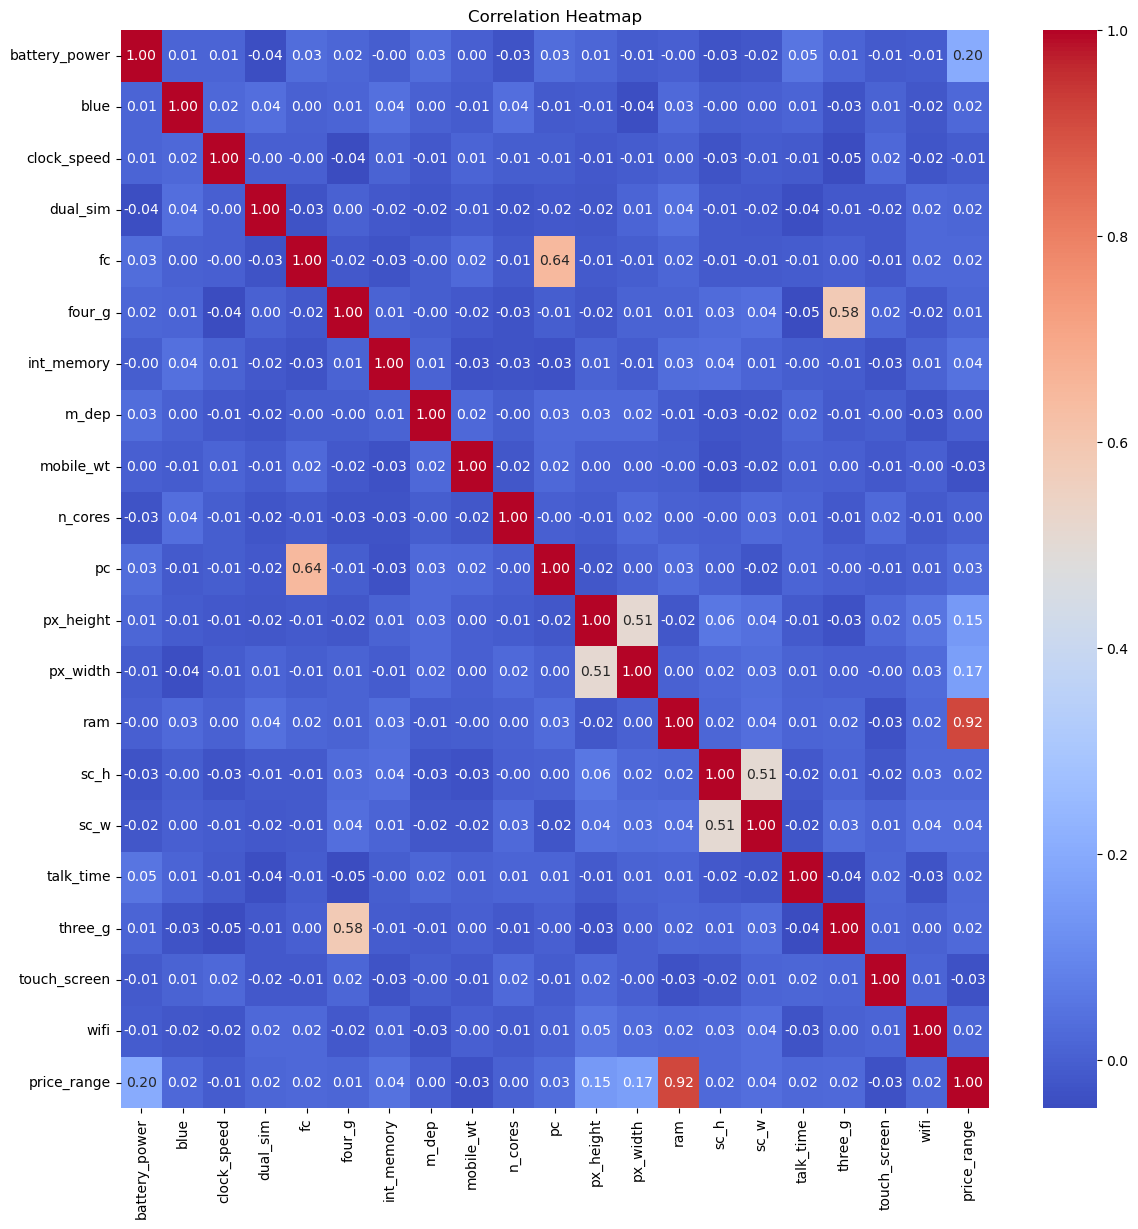

In [79]:
# Step 1 — Correlation Heatmap 

plt.figure(figsize=(14,14))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()      

### Correlation Heatmap : 
A correlation heatmap is a visual representation of the correlation between numerical features in a dataset. It helps identify the strength and direction of relationships between variables using color-coded values ranging from -1 to +1. 

# Rule of thumb : 
| Correlation | Meaning     |
| ----------- | ----------- |
| 0.90–1.00   | Very Strong |
| 0.70–0.90   | Strong      |
| 0.50–0.70   | Moderate    |
| 0.30–0.50   | Weak        |
| 0.00–0.30   | Very Weak   |

# OBSERVATIONS : 

- RAM is the highest predictor of price range. Highly correlated to price range i.e. influence price highest. 
- BATTERY POWER, FC, PX HEIGHT, PX WEIGHT, PC, FOUR G, THREE G have moderate influence on PRICE RANGE. 
- While other features like wifi, blue etc have very less influence as individual on price range.  

### Multicollinearity : 
Multicollinearity occurs when two or more independent features are highly correlated with each other, meaning they provide similar information. High multicollinearity can affect some machine learning models, especially linear models.

| Correlation | Meaning                     |
| ----------- | --------------------------- |
| <0.70       | Fine                        |
| 0.70–0.85   | Watch it                    |
| >0.85       | Potential multicollinearity |
| >0.95       | Usually remove one feature  |
 
- Front Camera ↔ Primary Camera = 0.64
- 3G ↔ 4G = 0.58
- Screen Height ↔ Screen Width = 0.51
- Pixel Height ↔ Pixel Width = 0.51
These are moderate correlations, not severe multicollinearity.

In [80]:
# Step 2 — Correlation with Target. -- df.corr()['price_range'].sort_values(ascending=False) -- 

corr = df.corr(numeric_only=True)

corr["price_range"].sort_values(ascending=False) 

price_range      1.000000
ram              0.917046
battery_power    0.200723
px_width         0.165818
px_height        0.148858
int_memory       0.044435
sc_w             0.038711
pc               0.033599
three_g          0.023611
sc_h             0.022986
fc               0.021998
talk_time        0.021859
blue             0.020573
wifi             0.018785
dual_sim         0.017444
four_g           0.014772
n_cores          0.004399
m_dep            0.000853
clock_speed     -0.006606
mobile_wt       -0.030302
touch_screen    -0.030411
Name: price_range, dtype: float64

## Observations

- **RAM (0.917)** has the strongest positive correlation with `price_range`, making it the most important feature.
- **Battery Power**, **Pixel Width**, and **Pixel Height** show weak positive correlations with the target.
- Most remaining features have correlation values close to **0**, indicating little or no meaningful linear relationship individually.
- Small negative values (e.g., Mobile Weight, Touch Screen) represent **negligible negative correlations**, not significant inverse relationships.

## Conclusion

Correlation identifies the strength of **linear relationships** only. Features with low correlation should not be removed solely based on this analysis, as they may still improve prediction when combined with other features or used in non-linear machine learning models. 

# MACHINE LEARNING PIPELINE. 

# Phase 5: Data Preprocessing
- Feature & Target Separation
- Train-Test Split
- Feature Scaling (if required)

In [81]:
# Step 1 – Separate Features and Target 

X = df.drop("price_range", axis=1)
y = df["price_range"]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape) 

Shape of X: (2000, 20)
Shape of y: (2000,)


## Feature and Target Separation

The dataset is divided into:

- **Features (X):** All independent variables used to predict the mobile price.
- **Target (y):** The `price_range` column, which the model will learn to predict. 

In [82]:
# Step 2 – Train-Test Split [80:20 split] 

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)  

In [83]:
# VERIFICATION : 

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape) 

X_train: (1600, 20)
X_test : (400, 20)
y_train: (1600,)
y_test : (400,)


# Feature Scaling : 

Feature Scaling transforms numerical features to a similar scale so that algorithms treat all features fairly, without being dominated by features that have larger numerical values. 

# Do we actually need scaling for this dataset? 
battery_power   501–1998
ram             256–3998
px_height       0–1960
px_width        500–1998
clock_speed     0.5–3.0
mobile_wt       80–200
m_dep           0.1–1.0 
Some features are in the thousands, while others are between 0 and 1. 

| Algorithm           | Scaling Needed?  |
| ------------------- | ---------------- |
| Logistic Regression | ✅ Yes           |
| KNN                 | ✅ Yes           |
| SVM                 | ✅ Yes           |
| Neural Networks     | ✅ Yes           |
| Decision Tree       | ❌ No            |
| Random Forest       | ❌ No            |
| XGBoost             | ❌ No            | 

There are 3 types of scalers : 
StandardScaler : [Transforms data to: Mean = 0, Standard Deviation = 1 Works well for most ML algorithms.] 
MinMaxScaler : Converts every value between 0 and 1. Mostly used in deep learning or image data. 
RobustScaler : Used when there are many outliers. 


In [84]:
# SCALER 

from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train) # FIT : The scaler learns from the training data. For every column it calculates: Mean, Standard deviation. TRANSFORM : Now it converts every value using the learned statistics. ex: (Original - mean)/ sd. 
X_test_scaled = scaler.transform(X_test)  

In [85]:
X_train_scaled.mean(axis=0)

array([-2.04281037e-16, -6.66133815e-18, -1.15463195e-16,  9.99200722e-17,
        3.60822483e-17,  1.14352972e-16,  2.88657986e-17, -1.15463195e-16,
        2.26485497e-16, -1.55431223e-17, -9.10382880e-17,  4.44089210e-17,
        2.60902411e-16, -1.50990331e-16,  1.40998324e-16,  9.32587341e-17,
       -1.02695630e-16,  1.53210777e-16, -7.66053887e-17,  6.43929354e-17])

In [86]:
X_train_scaled.std(axis=0) 

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1.])

# Phase 6: Model Comparison using 5-Fold Cross Validation 
- Train baseline models
- Cross Validation 

In [87]:
# LOGISTIC REGRESSION 

from sklearn.linear_model import LogisticRegression  # importing the model
model = LogisticRegression(random_state=42)          # create the model 
model.fit(X_train_scaled, y_train)                   # train the model  

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Baseline Model – Logistic Regression

A Logistic Regression model is trained to establish a baseline performance for the mobile price classification problem. Although its name contains "Regression," it is a classification algorithm.

The model learns patterns from the training data by assigning weights to each feature and uses these learned relationships to predict the target variable (`price_range`).

This baseline model will later be compared with more advanced models to determine whether feature engineering or complex algorithms improve performance.

In [88]:
# Prediction

y_pred = model.predict(X_test_scaled) 

In [89]:
# COMPARE 

print(y_pred[:20])
print(y_test[:20].values)

[3 1 0 2 3 2 0 0 1 0 3 0 0 1 3 3 2 0 1 3]
[3 1 0 2 3 2 0 0 1 0 3 0 0 1 3 3 2 0 1 3]


# Model 1: Logistic Regression 

In [90]:
# Step 1: Create the model 

from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(random_state=42)        # Setting random_state=42 ensures you get the same results every time you run the notebook, making your work reproducible. 

In [91]:
# Step 2: Perform 5-Fold Cross Validation 

from sklearn.model_selection import cross_val_score

lr_cv_scores = cross_val_score(
    lr_model,                       # → Logistic Regression model.
    X_train_scaled,                 # → Scaled training features (Logistic Regression requires scaling).
    y_train,                        # → Target values. 
    cv=5,                           # → Split the training data into 5 folds. 
    scoring="accuracy"              # → Measure accuracy for each fold. 
)  

In [92]:
# Step 3: View the Scores 

print("CV Scores:", lr_cv_scores)

CV Scores: [0.953125 0.940625 0.940625 0.95625  0.940625]


In [93]:
# Step 4: Calculate Mean Accuracy 

import numpy as np

lr_cv_mean = np.mean(lr_cv_scores)
print("Mean CV Accuracy:", lr_cv_mean)

Mean CV Accuracy: 0.94625


In [94]:
# Step 5: Calculate Standard Deviation

lr_cv_std = np.std(lr_cv_scores)
print("Standard Deviation:", lr_cv_std) 

Standard Deviation: 0.006959705453537519


In [95]:
# Step 6: Measure Training Time 

import time

start = time.time()

lr_cv_scores = cross_val_score(
    lr_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

end = time.time()

lr_time = end - start

print("Training Time:", lr_time) 

Training Time: 0.04193520545959473


# Logistic Regression

## Why Logistic Regression?
Logistic Regression is a supervised classification algorithm that predicts the probability of an observation belonging to a particular class. It serves as a strong baseline model because it is simple, interpretable, and computationally efficient.
- Cross-Validation Results
- Mean CV Accuracy: 94.63%
- Standard Deviation: 0.70%
- Scaling Required: Yes

## Observation
The model achieved a high average cross-validation accuracy with a low standard deviation, indicating consistent performance across different folds. This suggests that Logistic Regression generalizes well and provides a reliable baseline for comparison with more complex models.

# Model 2 : Decision Tree 

# What is a Decision Tree?
A Decision Tree is a supervised machine learning algorithm that makes decisions by asking a series of yes/no questions about the features. 
- Top node = Root
- Middle = Decision Nodes
- Bottom = Leaf Nodes (Predictions) 

In [96]:
from sklearn.tree import DecisionTreeClassifier 
dt_model = DecisionTreeClassifier(random_state=42)

In [97]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    dt_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("CV Scores:", cv_scores)
print("Average Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std()) 

CV Scores: [0.853125 0.846875 0.8375   0.796875 0.809375]
Average Accuracy: 0.82875
Standard Deviation: 0.021866069605669898


In [98]:
import time

start = time.time()

cross_val_score(
    dt_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

end = time.time()

print("Training Time:", end - start)

Training Time: 0.04662609100341797


## Decision Tree

### Why Decision Tree?
Decision Tree is a supervised machine learning algorithm that predicts the target variable by recursively splitting the dataset into smaller subsets based on feature values. It is easy to interpret, requires minimal data preprocessing, and can capture complex non-linear relationships.

### Cross Validation Results
- **CV Scores:** 85.31%, 84.69%, 83.75%, 79.69%, 80.94%
- **Mean CV Accuracy:** **82.88%**
- **Standard Deviation:** **2.19%**
- **Training Time:** **0.0556 seconds**
- **Scaling Required:** No

### Observation
- The Decision Tree achieved an average cross-validation accuracy of **82.88%**, which is significantly lower than Logistic Regression (**94.63%**).
- The standard deviation (**2.19%**) is higher than Logistic Regression (**0.70%**), indicating that the model's performance varies more across different folds.
- Although the training time is very fast, the lower accuracy and higher variability suggest that the default Decision Tree is overfitting the training data and does not generalize as well to unseen data.

### Conclusion
The default Decision Tree performs worse than Logistic Regression on this dataset. Therefore, Logistic Regression remains the better baseline model at this stage.

# Model 3: Random Forest

# What is Random Forest?
A Random Forest is an ensemble learning algorithm that combines many Decision Trees instead of relying on just one.
- Instead of asking: "What does one Decision Tree predict?"
- it asks: "What do hundreds of Decision Trees predict?"
The final prediction is made by majority voting.

In [99]:
from sklearn.ensemble import RandomForestClassifier 
rf_model = RandomForestClassifier(random_state=42)

In [100]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("CV Scores:", cv_scores)
print("Average Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

CV Scores: [0.86875  0.865625 0.86875  0.859375 0.878125]
Average Accuracy: 0.868125
Standard Deviation: 0.006059599821770428


In [101]:
import time

start = time.time()

cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

end = time.time()

print("Training Time:", end - start)

Training Time: 0.6721758842468262


## Random Forest

### Why Random Forest?
Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to improve prediction accuracy and reduce overfitting through majority voting.

### Cross Validation Results
- **Mean CV Accuracy:** **86.81%**
- **Standard Deviation:** **0.61%**
- **Training Time:** **0.8073 seconds**
- **Scaling Required:** No

### Observation
- Improved accuracy compared to Decision Tree (**82.88% → 86.81%**).
- Lower standard deviation indicates more stable performance.
- Still performed worse than Logistic Regression (**94.63%**).

### Conclusion
Random Forest is more robust than a single Decision Tree, but Logistic Regression remains the best-performing model on this dataset.

# Model 4 : K-Nearest Neighbors (KNN)

In [102]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5) 

In [103]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    knn_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("CV Scores:", cv_scores)
print("Average Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

CV Scores: [0.525    0.54375  0.465625 0.459375 0.496875]
Average Accuracy: 0.49812500000000004
Standard Deviation: 0.03275143126643475


In [104]:
import time

start = time.time()

cross_val_score(
    knn_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

end = time.time()

print("Training Time:", end - start)

Training Time: 0.05287814140319824


In [105]:
print(X_train_scaled.shape)
print(type(X_train_scaled))

(1600, 20)
<class 'numpy.ndarray'>


In [106]:
print(y_train.value_counts())

price_range
1    400
0    400
3    400
2    400
Name: count, dtype: int64


In [107]:
print(knn_model)

KNeighborsClassifier()


In [108]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

cv_scores = cross_val_score(
    knn_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("CV Scores:", cv_scores)
print("Average Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

CV Scores: [0.521875 0.540625 0.475    0.465625 0.49375 ]
Average Accuracy: 0.499375
Standard Deviation: 0.028187430709449207


In [109]:
knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)

from sklearn.metrics import accuracy_score

print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.5


In [110]:
print(np.isnan(X_train_scaled).sum())

0


In [111]:
print(X_train.columns.tolist())
print(X_test.columns.tolist())

['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g', 'touch_screen', 'wifi']
['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g', 'touch_screen', 'wifi']


# Model 5 : Support Vector Machine (SVM)   

In [112]:
from sklearn.svm import SVC 
svm_model = SVC(random_state=42) 

In [113]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    svm_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("CV Scores:", cv_scores)
print("Average Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std()) 

CV Scores: [0.853125 0.871875 0.840625 0.85     0.88125 ]
Average Accuracy: 0.859375
Standard Deviation: 0.01492167048289165


In [114]:
import time

start = time.time()

cross_val_score(
    svm_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

end = time.time()

print("Training Time:", end - start) 

Training Time: 0.29031968116760254


## Support Vector Machine (SVM)

### Why SVM?
Support Vector Machine (SVM) is a supervised learning algorithm that finds the optimal decision boundary (hyperplane) to separate different classes while maximizing the margin between them.

### Cross Validation Results
- **Mean CV Accuracy:** **85.94%**
- **Standard Deviation:** **1.49%**
- **Training Time:** **0.3125 seconds**
- **Scaling Required:** Yes

### Observation
- Achieved **85.94%** mean cross-validation accuracy.
- More stable than Decision Tree but less stable than Random Forest.
- Performed below Logistic Regression on this dataset.

### Conclusion
SVM is a strong classifier but did not outperform Logistic Regression for this problem.

# Model 6: Gaussian Naive Bayes (GaussianNB) 

In [115]:
from sklearn.naive_bayes import GaussianNB 
gnb_model = GaussianNB() 

In [116]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    gnb_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("CV Scores:", cv_scores)
print("Average Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std()) 

CV Scores: [0.796875 0.796875 0.8375   0.76875  0.79375 ]
Average Accuracy: 0.7987500000000001
Standard Deviation: 0.022061703243403487


In [117]:
import time

start = time.time()

cross_val_score(
    gnb_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

end = time.time()

print("Training Time:", end - start)

Training Time: 0.009930849075317383


## Gaussian Naive Bayes (GaussianNB)

### Why Gaussian Naive Bayes?
Gaussian Naive Bayes is a probabilistic classification algorithm based on Bayes' Theorem that assumes all features are independent.

### Cross Validation Results
- **Mean CV Accuracy:** **79.88%**
- **Standard Deviation:** **2.21%**
- **Training Time:** **0.0461 seconds**
- **Scaling Required:** No

### Observation
- Achieved **79.88%** mean cross-validation accuracy.
- Fastest model among all evaluated so far.
- Lowest accuracy, indicating that the independence assumption is not suitable for this dataset.

### Conclusion
Gaussian Naive Bayes provides a fast baseline but is not an ideal choice for this mobile price prediction problem. 

# Model 7: XGBoost 

In [118]:
from xgboost import XGBClassifier

print("XGBoost installed successfully!")

XGBoost installed successfully!


In [119]:
from xgboost import XGBClassifier 
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"         # Your dataset has 4 classes (0–3). This tells XGBoost to use multiclass log loss during training and avoids warning messages. 
) 

In [120]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("CV Scores:", cv_scores)
print("Average Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std()) 

CV Scores: [0.88125  0.884375 0.9      0.875    0.909375]
Average Accuracy: 0.89
Standard Deviation: 0.012716868718359895


In [121]:
import time

start = time.time()

cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

end = time.time()

print("Training Time:", end - start) 

Training Time: 1.4187650680541992


## XGBoost

### Why XGBoost?
XGBoost is an ensemble learning algorithm that builds decision trees sequentially, where each new tree learns from the mistakes of the previous trees to improve prediction accuracy.

### Cross Validation Results
- **Mean CV Accuracy:** **89.00%**
- **Standard Deviation:** **1.27%**
- **Training Time:** **1.7654 seconds**
- **Scaling Required:** No

### Observation
- Achieved **89.00%** mean cross-validation accuracy.
- Outperformed Decision Tree, Random Forest, SVM, and Gaussian Naive Bayes.
- Required the longest training time among all models.

### Conclusion
XGBoost is a strong ensemble model with high predictive performance, making it a good candidate for hyperparameter tuning. 

# Phase 6 Completed: Model Comparison 
| Model                |       Mean CV Accuracy |   Std Dev | Training Time (s) | Scaling Required | Status          |
| :------------------- | ---------------------: | --------: | ----------------: | :--------------: | :-------------- |
| Logistic Regression  |             **94.63%** | **0.70%** |        **0.1290** |         Yes        | ⭐ Best          |
| XGBoost              |             **89.00%** | **1.27%** |        **1.7654** |         No        | ⭐ Top Candidate |
| Random Forest        |             **86.81%** | **0.61%** |        **0.8073** |         No        | Completed       |
| SVM                  |             **85.94%** | **1.49%** |        **0.3125** |         Yes        | Completed       |
| Decision Tree        |             **82.88%** | **2.19%** |        **0.0556** |         No        | Completed       |
| Gaussian Naive Bayes |             **79.88%** | **2.21%** |        **0.0461** |         No        | Completed       |
| KNN                  | ⚠️ Under Investigation |         — |                 — |         Yes       | Pending         |


## Model Comparison Summary
Seven classification algorithms were evaluated using 5-fold cross-validation on the training dataset.

### Key Findings
- **Logistic Regression** achieved the highest mean cross-validation accuracy (**94.63%**) and served as the best baseline model.
- **XGBoost** was the second-best performer (**89.00%**) and showed strong predictive capability.
- **Random Forest** produced stable results with the lowest standard deviation (**0.61%**).
- **SVM** performed competitively but did not surpass Logistic Regression.
- **Decision Tree** and **Gaussian Naive Bayes** achieved comparatively lower accuracy.
- **KNN** produced unexpected results and will be investigated separately before further evaluation.

Based on these results, **Logistic Regression** and **XGBoost** were selected for hyperparameter tuning.

# KNN Investigation

In [122]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

k_values = [1,3,5,7,9,11,13,15,17,19,21]

cv_accuracy = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(
        knn,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    cv_accuracy.append(scores.mean())

for k, score in zip(k_values, cv_accuracy):
    print(f"K = {k} --> CV Accuracy = {score:.4f}") 

K = 1 --> CV Accuracy = 0.4588
K = 3 --> CV Accuracy = 0.4450
K = 5 --> CV Accuracy = 0.4981
K = 7 --> CV Accuracy = 0.5131
K = 9 --> CV Accuracy = 0.5306
K = 11 --> CV Accuracy = 0.5487
K = 13 --> CV Accuracy = 0.5594
K = 15 --> CV Accuracy = 0.5700
K = 17 --> CV Accuracy = 0.5800
K = 19 --> CV Accuracy = 0.5837
K = 21 --> CV Accuracy = 0.5863


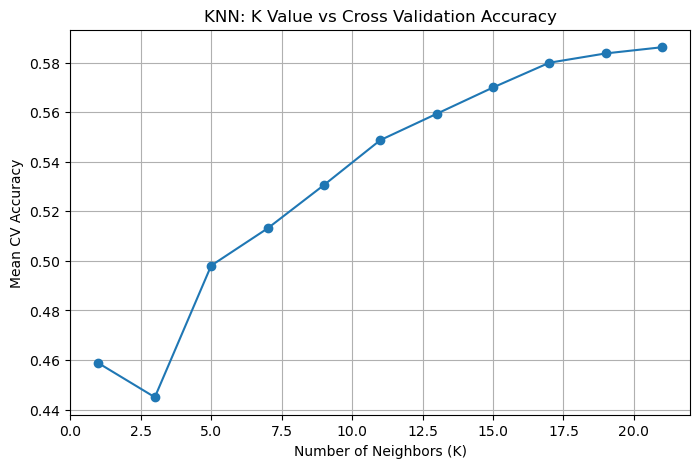

In [123]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(k_values, cv_accuracy, marker='o')

plt.title("KNN: K Value vs Cross Validation Accuracy")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Mean CV Accuracy")

plt.grid(True)

plt.show()

Increasing the number of neighbors improved KNN performance, but even the best value (k = 21) achieved only 58.63% mean cross-validation accuracy. Therefore, selecting a different k alone is insufficient to make KNN competitive for this dataset.

In [124]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

metrics = ["euclidean", "manhattan", "chebyshev"]

for metric in metrics:
    knn = KNeighborsClassifier(
        n_neighbors=21,
        metric=metric
    )

    scores = cross_val_score(
        knn,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    print(f"{metric}: {scores.mean():.4f}")

euclidean: 0.5863
manhattan: 0.6231
chebyshev: 0.3981


# KNN Investigation

## Investigation 1: Optimal K Value
Different values of **K** were evaluated using 5-fold cross-validation.

# Observation:
- Increasing the value of K gradually improved performance.
- The best result was obtained at **K = 21** with a mean CV accuracy of **58.63%**.
- However, the performance remained significantly lower than the other baseline models.

# Conclusion:
Changing the number of neighbors alone was not sufficient to make KNN competitive.

## Investigation 2: Distance Metric
Three distance metrics were compared using **K = 21**.
| Distance Metric | Mean CV Accuracy |
|----------------|-----------------:|
| Euclidean | 58.63% |
| Manhattan | **62.31%** |
| Chebyshev | 39.81% |

# Observation:
- Manhattan distance produced the highest accuracy.
- Chebyshev performed the worst.
- Although Manhattan improved the results, the accuracy was still considerably lower than the other models.

# Final Conclusion
After tuning the two most important hyperparameters (**K** and **distance metric**), KNN achieved a maximum mean cross-validation accuracy of **62.31%**.
Therefore, KNN was not selected for further hyperparameter tuning or final model selection because its performance remained substantially lower than the other evaluated algorithms. 

# Phase 7 : Hyperparameter Tuning 
Enhancing the model accuracy. 

- Logistic Regression 
- Random Forest 
- XGBoost

# Model 1: Logistic Regression Tuning [C, penalty, solver]  

In [125]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs", "newton-cg"]
}

grid_lr = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=1
)

grid_lr.fit(X_train_scaled, y_train)  

,estimator,LogisticRegre...ndom_state=42)
,param_grid,"{'C': [0.01, 0.1, ...], 'penalty': ['l2'], 'solver': ['lbfgs', 'newton-cg']}"
,scoring,'accuracy'
,n_jobs,1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [126]:
print("Best Parameters:", grid_lr.best_params_)
print("Best CV Accuracy:", grid_lr.best_score_)

Best Parameters: {'C': 100, 'penalty': 'l2', 'solver': 'newton-cg'}
Best CV Accuracy: 0.963125


In [127]:
import time

start = time.time()

grid_lr.fit(X_train_scaled, y_train)

end = time.time()

print("Training Time:", end - start)

Training Time: 0.4504687786102295


### Logistic Regression
- Best Parameters:
  - C = 100
  - penalty = l2
  - solver = newton-cg
- Best CV Accuracy: 96.31%
- Training Time: 0.66 sec

Observation:
Hyperparameter tuning improved the Logistic Regression model and achieved the highest cross-validation accuracy among all tested models. 

# Model 2: Random Forest Hyperparameter Tuning.  

In [128]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

In [129]:
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [130]:
rf_model = RandomForestClassifier(random_state=42)

random_rf = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=1
) 

In [131]:
random_rf.fit(X_train, y_train) 

,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,n_iter,20
,scoring,'accuracy'
,n_jobs,1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [132]:
print("Best Parameters:", random_rf.best_params_)
print("Best CV Accuracy:", random_rf.best_score_) 

Best Parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20}
Best CV Accuracy: 0.8712500000000001


In [133]:
import time

start = time.time()

random_rf.fit(X_train, y_train)

end = time.time()

print("Training Time:", end - start)

Training Time: 30.841537952423096


### Random Forest
- Best Parameters:
  - n_estimators = 300
  - max_depth = 20
  - min_samples_split = 5
  - min_samples_leaf = 1
- Best CV Accuracy: 87.13%
- Training Time: 30.06 sec

Observation:
Hyperparameter tuning slightly improved the Random Forest model, but its performance remained below Logistic Regression. 

# Model 3: XBoost Hyperparameter Tuning.    

In [134]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

In [135]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

random_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=1
) 

In [136]:
random_xgb.fit(X_train, y_train) 

,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,n_iter,20
,scoring,'accuracy'
,n_jobs,1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [137]:
print("Best Parameters:", random_xgb.best_params_)
print("Best CV Accuracy:", random_xgb.best_score_) 

Best Parameters: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best CV Accuracy: 0.9025000000000001


In [138]:
import time

start = time.time()

random_xgb.fit(X_train, y_train)

end = time.time()

print("Training Time:", end - start) 

Training Time: 54.84893584251404


### XGBoost
- Best Parameters:
  - n_estimators = 300
  - max_depth = 3
  - learning_rate = 0.05
  - subsample = 0.8
  - colsample_bytree = 1.0
- Best CV Accuracy: 90.25%
- Training Time: 59.45 sec

Observation:
Hyperparameter tuning improved XGBoost, but it still performed below Logistic Regression. 

| Model               | Best CV Accuracy | Training Time |
| ------------------- | ---------------: | ------------: |
| Logistic Regression |       **96.31%** |      0.66 sec |
| XGBoost             |           90.25% |     59.45 sec |
| Random Forest       |           87.13% |     30.06 sec |


# Phase 8 : Feature Engineering 

In [139]:
# Display Quality : screen_resolution = px_height * px_width  

# Step 1: Create the Feature 

X_train["screen_resolution"] = X_train["px_height"] * X_train["px_width"]
X_test["screen_resolution"] = X_test["px_height"] * X_test["px_width"] 

In [140]:
X_train[["px_height", "px_width", "screen_resolution"]].head()

,px_height,px_width,screen_resolution
469,292,695,202940
565,1350,1949,2631150
396,42,1161,48762
452,1017,1366,1389222
325,209,1078,225302


In [141]:
# Step 2: Scale Again

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  

In [142]:
# Step 3: Train the Tuned Logistic Regression 

from sklearn.linear_model import LogisticRegression

lr_feature = LogisticRegression(
    C=100,
    penalty="l2",
    solver="newton-cg",
    random_state=42
)

lr_feature.fit(X_train_scaled, y_train) 

,penalty,'l2'
,dual,False
,tol,0.0001
,C,100
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'newton-cg'
,max_iter,100
,multi_class,'deprecated'


In [143]:
# Step 4: Cross Validation 

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    lr_feature,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean()) 

CV Scores: [0.975    0.9375   0.965625 0.96875  0.9625  ]
Mean CV Accuracy: 0.961875


In [144]:
from sklearn.metrics import accuracy_score

y_pred = lr_feature.predict(X_test_scaled)

test_accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", test_accuracy) 

Test Accuracy: 0.9825


| Model                                | Mean CV Accuracy | Test Accuracy |
| ------------------------------------ | ---------------: | ------------: |
| Tuned Logistic Regression (Original) |       **96.31%** |     **96.5%** |
| + Screen Resolution                  |       **96.19%** |    **98.25%** |


So dropping. 

In [145]:
# DROP 

X_train.drop(columns=["screen_resolution"], inplace=True)
X_test.drop(columns=["screen_resolution"], inplace=True)

In [146]:
# Camera Power  

X_train["camera_power"] = X_train["pc"] + X_train["fc"]
X_test["camera_power"] = X_test["pc"] + X_test["fc"]

In [147]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [148]:
from sklearn.linear_model import LogisticRegression

lr_feature = LogisticRegression(
    C=100,
    penalty="l2",
    solver="newton-cg",
    random_state=42
)

lr_feature.fit(X_train_scaled, y_train) 

,penalty,'l2'
,dual,False
,tol,0.0001
,C,100
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'newton-cg'
,max_iter,100
,multi_class,'deprecated'


In [149]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    lr_feature,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean()) 

CV Scores: [0.978125 0.94375  0.965625 0.96875  0.959375]
Mean CV Accuracy: 0.963125


In [150]:
from sklearn.metrics import accuracy_score

y_pred = lr_feature.predict(X_test_scaled)

test_accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", test_accuracy) 

Test Accuracy: 0.9825


| Feature           |      Mean CV | Test Accuracy | Decision   |
| ----------------- | -----------: | ------------: | ---------- |
| Baseline          | **0.963125** |    **0.9650** | —          |
| Screen Resolution |     0.961875 |        0.9825 |   Remove   |
| Camera Power      | **0.963125** |    **0.9825** |    Neutral |


In [151]:
# DROP 

X_train.drop(columns=["camera_power"], inplace=True)
X_test.drop(columns=["camera_power"], inplace=True)

# Battery Efficiency

## Business Idea
A phone with a large battery and efficient hardware (more CPU cores) may perform better than one with only a large battery.

We'll define:
                   Battery Efficiency = battery_power / n_cores  

This is a reasonable hypothesis because it measures battery available per processing core.

In [152]:
# Battery Efficiency  

X_train["battery_efficiency"] = (
    X_train["battery_power"] / X_train["n_cores"]
)

X_test["battery_efficiency"] = (
    X_test["battery_power"] / X_test["n_cores"]
)

In [153]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) 

In [154]:
from sklearn.linear_model import LogisticRegression

lr_feature = LogisticRegression(
    C=100,
    penalty="l2",
    solver="newton-cg",
    random_state=42
)

lr_feature.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,100
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'newton-cg'
,max_iter,100
,multi_class,'deprecated'


In [155]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    lr_feature,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean()) 

CV Scores: [0.975   0.94375 0.9625  0.96875 0.95625]
Mean CV Accuracy: 0.96125


In [156]:
from sklearn.metrics import accuracy_score

y_pred = lr_feature.predict(X_test_scaled)

test_accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", test_accuracy) 

Test Accuracy: 0.9775


In [157]:
X_train.drop(columns=["battery_efficiency"], inplace=True)
X_test.drop(columns=["battery_efficiency"], inplace=True)

# Screen Area
This is one of the strongest feature engineering ideas for this dataset.

## Business intuition
A phone's display size depends on both its height and width.
Instead of treating them independently, combine them into one feature:

Screen Area = sc_h ​× sc_w​ 

This captures the overall display area, which could correlate with premium phones.

In [158]:
# Screen Area  # Performance Score 

X_train["screen_area"] = X_train["sc_h"] * X_train["sc_w"]
X_test["screen_area"] = X_test["sc_h"] * X_test["sc_w"]

In [159]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [160]:
from sklearn.linear_model import LogisticRegression

lr_feature = LogisticRegression(
    C=100,
    penalty="l2",
    solver="newton-cg",
    random_state=42
)

lr_feature.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,100
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'newton-cg'
,max_iter,100
,multi_class,'deprecated'


In [161]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    lr_feature,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

CV Scores: [0.98125  0.940625 0.965625 0.9625   0.9625  ]
Mean CV Accuracy: 0.9625


In [162]:
from sklearn.metrics import accuracy_score

y_pred = lr_feature.predict(X_test_scaled)

test_accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.98


| Feature            |      Mean CV | Test Accuracy | Decision  |
| ------------------ | -----------: | ------------: | --------- |
| Baseline           | **96.3125%** |    **96.50%** | Baseline  |
| Screen Resolution  |     96.1875% |        98.25% |   Remove  |
| Camera Power       |     96.3125% |        98.25% |   Neutral |
| Battery Efficiency |     96.1250% |        97.75% |   Remove  |
| Screen Area        |     96.2500% |        98.00% |   Remove  |


In [163]:
X_train.drop(columns=["screen_area"], inplace=True)
X_test.drop(columns=["screen_area"], inplace=True) 

# Performance Score 
This is the feature I've been most interested in testing.

## Business intuition
A phone isn't powerful because of RAM alone or CPU speed alone.
It's powerful when both work together.

Instead of treating them separately, combine them: performance_score = ram × clock_speed  

In [164]:
X_train["performance_score"] = (
    X_train["ram"] * X_train["clock_speed"]
)

X_test["performance_score"] = (
    X_test["ram"] * X_test["clock_speed"]
)

In [165]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [166]:
from sklearn.linear_model import LogisticRegression

lr_feature = LogisticRegression(
    C=100,
    penalty="l2",
    solver="newton-cg",
    random_state=42
)

lr_feature.fit(X_train_scaled, y_train) 

,penalty,'l2'
,dual,False
,tol,0.0001
,C,100
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'newton-cg'
,max_iter,100
,multi_class,'deprecated'


In [167]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    lr_feature,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean()) 

CV Scores: [0.978125 0.940625 0.965625 0.971875 0.959375]
Mean CV Accuracy: 0.963125


In [168]:
from sklearn.metrics import accuracy_score

y_pred = lr_feature.predict(X_test_scaled)

test_accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", test_accuracy) 

Test Accuracy: 0.9825


| Feature            |      Mean CV | Test Accuracy | Decision  |
| ------------------ | -----------: | ------------: | --------- |
| Baseline           | **96.3125%** |    **96.50%** | Baseline  |
| Screen Resolution  |     96.1875% |        98.25% | ❌ Remove  |
| Camera Power       |     96.3125% |        98.25% | ➖ Neutral |
| Battery Efficiency |     96.1250% |        97.75% | ❌ Remove  |
| Screen Area        |     96.2500% |        98.00% | ❌ Remove  |
| Performance Score  | **96.3125%** |    **98.25%** | ➖ Neutral |


In [169]:
X_train.drop(columns=["performance_score"], inplace=True)
X_test.drop(columns=["performance_score"], inplace=True) 

Several domain-inspired features were engineered based on business intuition, including Screen Resolution, Camera Power, Battery Efficiency, Screen Area, and Performance Score. Each feature was evaluated independently using the tuned Logistic Regression model and 5-fold cross-validation. None of the engineered features improved the baseline cross-validation accuracy, indicating that the original dataset already captured the necessary predictive information. Therefore, the engineered features were discarded, and the original feature set was retained. 

# Phase 9
│
├── Build Pipeline
├── Evaluate different K values
├── Select Best K
├── Train Final Pipeline
├── Test Accuracy
└── Selected Features

# Feature Selection 
Choosing the most important existing features and removing less useful ones. 

| Method                           | Why?                   |  Keep? |
| -------------------------------- | ---------------------- | :----: |
| SelectKBest                      | Statistical importance |    ✅   |
| RFE                              | Model-based selection  |    ✅   |
| Random Forest Feature Importance | Tree importance        | ❌ Skip |
| XGBoost Feature Importance       | Very similar to RF     | ❌ Skip |


# Method 1 : SelectKBest    

In [170]:
# Step 1 – Imports 

from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [171]:
# Step 2 – Create the Pipeline 

from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("selector", SelectKBest(score_func=f_classif)),
    ("model", LogisticRegression(
        C=100,
        solver="newton-cg",
        max_iter=1000,
        random_state=42
    ))
]) 

In [172]:
# Step 3 – Search for the Best Number of Features 

param_grid = {
    "selector__k": [5, 10, 15, 20]
} 

In [173]:
# Step 4 – GridSearchCV 

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=1
)

grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...newton-cg'))])
,param_grid,"{'selector__k': [5, 10, ...]}"
,scoring,'accuracy'
,n_jobs,1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [174]:
# Step 5 – Display the Results

print("Best Number of Features:", grid_search.best_params_["selector__k"])
print("Best CV Accuracy:", grid_search.best_score_)

Best Number of Features: 10
Best CV Accuracy: 0.97


In [175]:
# Step 6 – Best Pipeline 

best_pipeline = grid_search.best_estimator_ 

In [176]:
# Step 7 – Test Accuracy 

y_pred = best_pipeline.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.985


In [177]:
# Step 8 – Selected Features 

selected_features = X_train.columns[
    best_pipeline.named_steps["selector"].get_support()
]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['battery_power', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores',
       'px_height', 'px_width', 'ram', 'sc_h', 'talk_time'],
      dtype='object')


In [178]:
# Step 9 – Show All Results 

import pandas as pd

results = pd.DataFrame(grid_search.cv_results_)

results = results[
    ["param_selector__k", "mean_test_score", "std_test_score"]
]

results = results.sort_values(
    by="mean_test_score",
    ascending=False
)

results 

,param_selector__k,mean_test_score,std_test_score
1,10,0.970000,0.010570
3,20,0.963125,0.011422
2,15,0.962500,0.006847
0,5,0.953125,0.010078


# Method 2 : RFE  

In [180]:
from sklearn.feature_selection import RFE

In [181]:
pipeline_rfe = Pipeline([
    ("scaler", StandardScaler()),
    ("selector", RFE(
        estimator=LogisticRegression(
            C=100,
            solver="newton-cg",
            max_iter=1000,
            random_state=42
        )
    )),
    ("model", LogisticRegression(
        C=100,
        solver="newton-cg",
        max_iter=1000,
        random_state=42
    ))
])

In [182]:
param_grid_rfe = {
    "selector__n_features_to_select": [5, 10, 15, 20]
} 

In [183]:
grid_search_rfe = GridSearchCV(
    estimator=pipeline_rfe,
    param_grid=param_grid_rfe,
    cv=5,
    scoring="accuracy",
    n_jobs=1
)

grid_search_rfe.fit(X_train, y_train) 

,estimator,Pipeline(step...newton-cg'))])
,param_grid,"{'selector__n_features_to_select': [5, 10, ...]}"
,scoring,'accuracy'
,n_jobs,1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [185]:
print("Best Number of Features:",
      grid_search_rfe.best_params_["selector__n_features_to_select"])

print("Best CV Accuracy:",
      f"{grid_search_rfe.best_score_:.4f}")   

Best Number of Features: 5
Best CV Accuracy: 0.9719


In [186]:
best_pipeline_rfe = grid_search_rfe.best_estimator_

In [187]:
y_pred = best_pipeline_rfe.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.9875


In [188]:
selected_features_rfe = X_train.columns[
    best_pipeline_rfe.named_steps["selector"].get_support()
]

selected_features_rfe

Index(['battery_power', 'mobile_wt', 'px_height', 'px_width', 'ram'], dtype='object')

In [189]:
comparison = pd.DataFrame({
    "SelectKBest": pd.Series(selected_features),
    "RFE": pd.Series(selected_features_rfe)
})

comparison

,SelectKBest,RFE
0,battery_power,battery_power
1,int_memory,mobile_wt
2,m_dep,px_height
3,mobile_wt,px_width
4,n_cores,ram
5,px_height,NaN
6,px_width,NaN
7,ram,NaN
8,sc_h,NaN
9,talk_time,NaN


| Method      | Features | CV Accuracy | Test Accuracy |
| ----------- | -------: | ----------: | ------------: |
| SelectKBest |       10 |      97.00% |        98.50% |
| **RFE**     |    **5** |  **97.19%** |  **98.75%** ✅ |


Two feature selection methods were evaluated using leakage-free pipelines and 5-fold cross-validation: SelectKBest and Recursive Feature Elimination (RFE). Although both methods achieved excellent performance, RFE produced the highest cross-validation accuracy (97.19%) and test accuracy (98.75%) while selecting only five features. Therefore, RFE was chosen as the final feature selection method because it achieved the best predictive performance with a simpler feature set.

# Final selected features : 
battery_power
mobile_wt
px_height
px_width
ram 

# Phase 10 – Final Model & Prediction 

Final Decisions : 
| Component          | Final Choice              |
| ------------------ | ------------------------- |
| Model              | Logistic Regression       |
| Hyperparameters    | C=100, solver="newton-cg" |
| Feature Selection  | RFE                       |
| Number of Features | 5                         |
| Preprocessing      | StandardScaler            |
| Validation         | 5-Fold CV                 |
| Final Pipeline     | RFE Pipeline              |


In [191]:
# Step 1 – Create Final Training Data 

X_final = df.drop("price_range", axis=1)
y_final = df["price_range"]

In [192]:
# Step 2 – Build Final Pipeline 

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

final_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("selector", RFE(
        estimator=LogisticRegression(
            C=100,
            solver="newton-cg",
            max_iter=1000,
            random_state=42
        ),
        n_features_to_select=5
    )),
    ("model", LogisticRegression(
        C=100,
        solver="newton-cg",
        max_iter=1000,
        random_state=42
    ))
])

In [193]:
# Step 3 – Train the Final Model 

final_pipeline.fit(X_final, y_final) 

,steps,"[('scaler', ...), ('selector', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,estimator,LogisticRegre...r='newton-cg')
,n_features_to_select,5
,step,1
,verbose,0


In [195]:
test_df = pd.read_csv("test.csv")

test_df.head() 

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1,1043,1,1.8,1,14,0,5,0.1,193,...,16,226,1412,3476,12,7,2,0,1,0
1,2,841,1,0.5,1,4,1,61,0.8,191,...,12,746,857,3895,6,0,7,1,0,0
2,3,1807,1,2.8,0,1,0,27,0.9,186,...,4,1270,1366,2396,17,10,10,0,1,1
3,4,1546,0,0.5,1,18,1,25,0.5,96,...,20,295,1752,3893,10,0,7,1,1,0
4,5,1434,0,1.4,0,11,1,49,0.5,108,...,18,749,810,1773,15,8,7,1,0,1


In [196]:
test_df.shape

(1000, 21)

In [197]:
# Phase 10 – Predict on test.csv
# Step 4 – Separate the ID 

test_ids = test_df["id"]

In [198]:
# Step 5 – Remove the ID Column 

X_final_test = test_df.drop("id", axis=1) 

In [199]:
# Step 6 – Generate Predictions 

predictions = final_pipeline.predict(X_final_test) 

In [200]:
# Step 7 – Create Submission DataFrame 

submission = pd.DataFrame({
    "id": test_ids,
    "price_range": predictions
}) 

In [201]:
# Step 8 – Preview Predictions 

submission.head() 

,id,price_range
0,1,3
1,2,3
2,3,2
3,4,3
4,5,1


In [202]:
# Step 9 – Save the Predictions 

submission.to_csv("submission.csv", index=False)

print("submission.csv saved successfully!") 

submission.csv saved successfully!


# Project Summary

## Dataset
- Training Samples: 2000
- Test Samples: 1000
- Features: 20
- Target: Price Range (0–3)

## Workflow
- Data Cleaning
- Exploratory Data Analysis
- Correlation Analysis
- Data Preprocessing
- Baseline Model Comparison
- Hyperparameter Tuning
- Feature Engineering
- Feature Selection (SelectKBest & RFE)
- Final Model Training
- Test Set Prediction

## Final Model
- Logistic Regression
- StandardScaler
- Recursive Feature Elimination (RFE)
- 5 Selected Features

## Final Performance
- Cross-Validation Accuracy: **97.19%**
- Test Accuracy: **98.75%**

## Selected Features
- Battery Power
- Mobile Weight
- Pixel Height
- Pixel Width
- RAM

In [203]:
df.head() 

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [205]:
test_df.head() 

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1,1043,1,1.8,1,14,0,5,0.1,193,...,16,226,1412,3476,12,7,2,0,1,0
1,2,841,1,0.5,1,4,1,61,0.8,191,...,12,746,857,3895,6,0,7,1,0,0
2,3,1807,1,2.8,0,1,0,27,0.9,186,...,4,1270,1366,2396,17,10,10,0,1,1
3,4,1546,0,0.5,1,18,1,25,0.5,96,...,20,295,1752,3893,10,0,7,1,1,0
4,5,1434,0,1.4,0,11,1,49,0.5,108,...,18,749,810,1773,15,8,7,1,0,1


# PIPELINE : 

X_final_test (20 features)
          │
          ▼
StandardScaler
          │
          ▼
RFE
     ↓ Keeps only 5 features
          │
          ▼
Logistic Regression
          │
          ▼
Prediction 

# Like filter : 

20 Documents
      │
      ▼
Security Guard (RFE)
      │
Allows only 5 documents
      ▼
Manager (Logistic Regression)

In [206]:
best_pipeline_rfe.named_steps["selector"].get_support()  # True features are ones kept. 

array([ True, False, False, False, False, False, False, False,  True,
       False, False,  True,  True,  True, False, False, False, False,
       False, False])

In [207]:
X_final_test.columns[
    final_pipeline.named_steps["selector"].get_support()
] 

Index(['battery_power', 'mobile_wt', 'px_height', 'px_width', 'ram'], dtype='object')

In [210]:
pd.Series(predictions).value_counts().sort_index() 

0    258
1    223
2    259
3    260
Name: count, dtype: int64

| Stage                       | Model                                           |    CV Accuracy |  Test Accuracy | Status                        |
| --------------------------- | ----------------------------------------------- | -------------: | -------------: | ----------------------------- |
| Baseline (before tuning)    | Logistic Regression                             |     **94.63%** |     **96.50%** | Initial model                 |
| After Hyperparameter Tuning | Logistic Regression                             |     **96.31%** |     **96.50%** | Improved CV                   |
| After Feature Engineering   | Logistic Regression                             | No improvement | No improvement | Discarded engineered features |
| SelectKBest                 | Logistic Regression + SelectKBest (10 features) |     **97.00%** |     **98.50%** | Better                        |
| **Final Model**             | **Logistic Regression + RFE (5 features)**      |     **97.19%** |     **98.75%** | ✅ Chosen                      | 

In [212]:
from sklearn.metrics import accuracy_score

train_predictions = final_pipeline.predict(X_final)

train_accuracy = accuracy_score(y_final, train_predictions)

print(f"Training Accuracy: {train_accuracy:.4f}") 

Training Accuracy: 0.9790
